# 원룸 사진 기반 3D 공간 복원 및 거리 측정  (v4.0 - 객체 라벨링)

v3.0(거리측정)에 **객체 라벨링 + oriented bbox 흡수**를 추가한 버전이다.
SAM2 마스크가 뷰마다 불완전하게 잡히는 문제(예: 한 뷰는 매트리스까지, 다른 뷰는 프레임만)를
3D 점군 단계에서 통합해 해결한다. 한 뷰라도 잡은 객체는 3D에서 그 점들을 감싸는
직육면체(oriented bbox) 안의 점을 모두 같은 객체로 재라벨링한다.

핵심 원리: "주변을 다 같은 객체로" 보는 게 아니라, "이미 객체로 잡힌 점들이 차지하는
부피 안"의 점만 흡수한다. 매트리스는 프레임 바로 위(=침대 부피 안)라 흡수되고,
옆 바닥·벽은 부피 밖이라 흡수되지 않는다.

스케일 기준은 **천장고**다 (한국 주거 표준 2.3~2.4m).

구성: 0 환경설정 / 1 데이터 / 2 DUSt3R 복원 / 2-1 입력 진단 / 3 좌표 정렬(핵심) /
3-1 객체 라벨링(신규) / 3-2 bbox 흡수(신규) / 3-3 라벨 검증(신규) /
4 GLB 저장 / 5 천장고 기반 스케일 계산 / 6 두 점 클릭 거리 측정


## 0. 환경 설정

In [1]:
import os
import sys
import glob
import shutil
import numpy as np
from PIL import Image

# DUSt3R 저장소 클론 (이미 존재하면 건너뜀)
if not os.path.exists("/content/dust3r"):
    !git clone --recursive https://github.com/naver/dust3r.git /content/dust3r

%cd /content/dust3r
!pip install -q -r requirements.txt
!pip install -q open3d shapely trimesh scipy roma plotly
%cd /content

# DUSt3R 모듈 경로 등록 (중복 방지)
if "/content/dust3r" not in sys.path:
    sys.path.insert(0, "/content/dust3r")


Cloning into '/content/dust3r'...
remote: Enumerating objects: 611, done.
remote: Total 611 (delta 0), reused 0 (delta 0), pack-reused 611 (from 1)
Receiving objects: 100% (611/611), 756.60 KiB | 36.03 MiB/s, done.
Resolving deltas: 100% (355/355), done.
Submodule 'croco' (https://github.com/naver/croco) registered for path 'croco'
Cloning into '/content/dust3r/croco'...
remote: Enumerating objects: 198, done.        
remote: Counting objects: 100% (87/87), done.        
remote: Compressing objects: 100% (54/54), done.        
remote: Total 198 (delta 54), reused 33 (delta 33), pack-reused 111 (from 1)        
Receiving objects: 100% (198/198), 403.93 KiB | 19.23 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Submodule path 'croco': checked out 'd7de0705845239092414480bd829228723bf20de'
/content/dust3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [1]:
from google.colab import drive
drive.mount("/content/drive")

In [2]:
# 한글 폰트 설치 및 matplotlib 등록
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")


한글 폰트 설정 완료


## 1. 데이터 다운로드 및 폴더 선택

In [3]:
# Google Drive 폴더 다운로드
!gdown --folder 1ivpuKwZ25BosAlM9-YnROKlNPpPk-6Op

print("\n다운로드된 파일 목록")
for root, dirs, files in os.walk("/content/02_Data"):
    for f in files:
        print(" ", os.path.join(root, f))


Retrieving folder contents
Retrieving folder 1tlF8IorjPl4yApnpa3dV9k3daj7ySpXt room01
Processing file 1F6HCnLOskrG5rB-ZI0oPBrFP0fx3lHAR img_01.jpg
Processing file 1dS3Gr9B3Cq0D_m82ru1ouc3n1i1V1J8I img_02.jpg
Processing file 1OxHHFMNImbaKxHHgyDFni4auNnwA5Gks img_03.jpg
Retrieving folder 1QyxEoFSjNWCM5GAMOovKFnzqP_f8IfQo room02
Processing file 1x-FokINTobcxKIabmlYJR1iJ3VR9iPFH img_01.jpg
Processing file 1VWGkQRlgwJzaW9_wtsNy4LWNJ6f82BIn img_02.jpg
Processing file 18DpTym0GHNe8MhO4EtRkPdPvOmzRr6BO img_03.jpg
Processing file 1jG9Vg746Mw9fvIuFvcHCdmmGAvXBVhDG img_04.jpg
Retrieving folder 1qWJRyDFjJ8Ub3tXVvSoqrWyemyAs7-uK room03
Processing file 1ZyqCPVlg0CrR0J3aqSJG_tB6mos7j9Dl img_01.jpg
Processing file 1btFz1lx2FqGXdHQC5XFz0TdPhNWZENp7 img_02.jpg
Processing file 1yeq4N8sx4mBBgYpv6PYVPsfqnlFwiSlt img_03.jpg
Retrieving folder 1OlEaraXTTD3dnHDDR0akY2lJC8BJj-bX room04
Processing file 1eSFzYp6PzX8pZS0hG3niSrtCWnSgoSWL img_01.jpg
Processing file 1nXA79OZYdQwogJAeVgGKUoNxA2kXhWIn img_02.jpg
Proce

In [38]:
# 처리 대상 폴더 지정
# 선택지: test1 / test2 / test3 / test4 / 직방사진
TARGET_FOLDER = "test1"

# 신뢰도 임계값 (DUSt3R confidence 필터링 기준)
CONF_THR = 1.0 # 높을수록 노이즈 제거 너무 올리면 구멍생길수도..

# 이미지 경로 수집
target_path = f"/content/02_Data/{TARGET_FOLDER}"
img_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    img_paths.extend(glob.glob(os.path.join(target_path, ext)))
img_paths = sorted(img_paths)

print(f"[{TARGET_FOLDER}] 이미지 {len(img_paths)}장")
for p in img_paths:
    print(" ", os.path.basename(p))

# 이후 단계에서 원본 PIL 이미지가 필요하므로 미리 로드
images_pil = [Image.open(p).convert("RGB") for p in img_paths]


[test1] 이미지 3장
  6a2faabef0290_origin.jpg
  6a2faabf730ea_origin.jpg
  6a2faabfd9ec4_origin.jpg


## 2. 3D 복원 (DUSt3R)

In [5]:
import torch
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference
from dust3r.cloud_opt import global_aligner

# DUSt3R 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device)
model.eval()
print(f"DUSt3R 모델 로드 완료 (device: {device})")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/content/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

DUSt3R 모델 로드 완료 (device: cuda)


In [39]:
# 이미지 로드 및 쌍 구성 후 추론
images_dust3r = load_images(img_paths, size=512)
pairs = make_pairs(images_dust3r, scene_graph="complete", prefilter=None, symmetrize=True)
print(f"이미지 쌍 {len(pairs)}개 구성")

with torch.no_grad():
    output = inference(pairs, model, device, batch_size=2)

# Global alignment로 전체 좌표계 정렬
scene = global_aligner(output, device=device)
scene.compute_global_alignment(niter=300, init="mst")
print("3D 복원 및 정렬 완료")


>> Loading a list of 3 images
 - adding /content/02_Data/test1/6a2faabef0290_origin.jpg with resolution 1086x1448 --> 384x512
 - adding /content/02_Data/test1/6a2faabf730ea_origin.jpg with resolution 1086x1448 --> 384x512
 - adding /content/02_Data/test1/6a2faabfd9ec4_origin.jpg with resolution 1086x1448 --> 384x512
 (Found 3 images)
이미지 쌍 6개 구성
>> Inference with model on 6 image pairs


  0%|          | 0/3 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 3/3 [00:01<00:00,  2.29it/s]


 init edge (1*,0*) score=np.float64(393.0160217285156)
 init edge (1,2*) score=np.float64(251.31173706054688)
 init loss = 0.012099227868020535
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 300/300 [00:05<00:00, 54.37it/s, lr=1.27413e-06 loss=0.00921046]

3D 복원 및 정렬 완료


## 2-1. 입력 품질 진단

In [40]:
# --- confidence 통계 ---
conf_list = [c.detach().cpu().numpy() for c in scene.get_conf()]

print("=== 뷰별 confidence ===")
for i, c in enumerate(conf_list):
    print(f"  view {i}: mean={c.mean():.2f}  median={np.median(c):.2f}  "
          f"min={c.min():.2f}  max={c.max():.2f}")

overall = np.mean([c.mean() for c in conf_list])
print(f"\n전체 평균 confidence: {overall:.2f}")
if overall < 3.0:
    print(">> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.")
    print(">> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.")
else:
    print(">> confidence 양호.")


=== 뷰별 confidence ===
  view 0: mean=2.89  median=3.12  min=0.00  max=3.61
  view 1: mean=2.98  median=3.08  min=0.05  max=3.69
  view 2: mean=2.79  median=2.98  min=0.04  max=3.49

전체 평균 confidence: 2.88
>> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.
>> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.


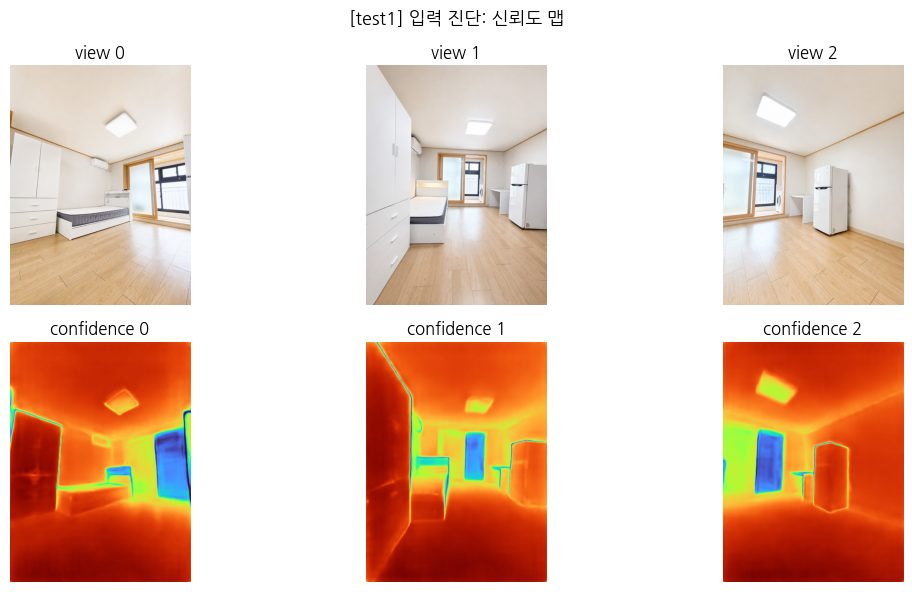

아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음


In [41]:
import matplotlib.pyplot as plt
# --- confidence 맵 시각화 ---
imgs_np = scene.imgs   # 정규화된 입력 (H,W,3), 0~1
n = len(imgs_np)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
if n == 1:
    axes = np.array(axes).reshape(2, 1)
for i in range(n):
    axes[0, i].imshow(imgs_np[i]); axes[0, i].set_title(f"view {i}"); axes[0, i].axis("off")
    axes[1, i].imshow(conf_list[i], cmap="turbo")
    axes[1, i].set_title(f"confidence {i}"); axes[1, i].axis("off")
plt.suptitle(f"[{TARGET_FOLDER}] 입력 진단: 신뢰도 맵", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음")


**확인 포인트 — 입력 진단 해석**
- confidence가 전반적으로 낮으면 거리 측정값도 신뢰하기 어렵다. 시점이 겹치는 사진을 더 확보하는 게 근본 해결책이다.
- 카메라 분산이 너무 작으면(한 자리에서만 찍음) 복원이 평면적으로 무너져 거리 오차가 커진다.


In [51]:
!pip install -q ultralytics
from ultralytics import YOLO
import cv2

# YOLO11 large 모델 로드 (가구 검출 정확도 우선)
model_yolo = YOLO("/content/drive/Othercomputers/내 노트북/Asac-DL-Team4/02_Data/yolo11s_1074_832_final_20260703.pt")
print("YOLO 모델 로드 완료")

YOLO 모델 로드 완료


In [52]:
# 객체 검출 실행 (conf: 신뢰도 임계값)
results_yolo = []
for path in img_paths:
    result = model_yolo(path, conf=0.4)
    results_yolo.append(result[0])

    print(f"\n{os.path.basename(path)}")
    for box in result[0].boxes:
        cls_name = model_yolo.names[int(box.cls)]
        print(f"  {cls_name} ({float(box.conf):.2f})")


image 1/1 /content/02_Data/test1/6a2faabef0290_origin.jpg: 832x640 1 bed, 1 wardrob, 11.5ms
Speed: 4.3ms preprocess, 11.5ms inference, 1.5ms postprocess per image at shape (1, 3, 832, 640)

6a2faabef0290_origin.jpg
  bed (0.86)
  wardrob (0.85)

image 1/1 /content/02_Data/test1/6a2faabf730ea_origin.jpg: 832x640 1 bed, 1 desk, 1 refrigerator, 1 wardrob, 10.7ms
Speed: 4.0ms preprocess, 10.7ms inference, 1.8ms postprocess per image at shape (1, 3, 832, 640)

6a2faabf730ea_origin.jpg
  refrigerator (0.86)
  bed (0.81)
  desk (0.67)
  wardrob (0.60)

image 1/1 /content/02_Data/test1/6a2faabfd9ec4_origin.jpg: 832x640 1 desk, 1 refrigerator, 11.4ms
Speed: 4.2ms preprocess, 11.4ms inference, 1.5ms postprocess per image at shape (1, 3, 832, 640)

6a2faabfd9ec4_origin.jpg
  refrigerator (0.89)
  desk (0.62)


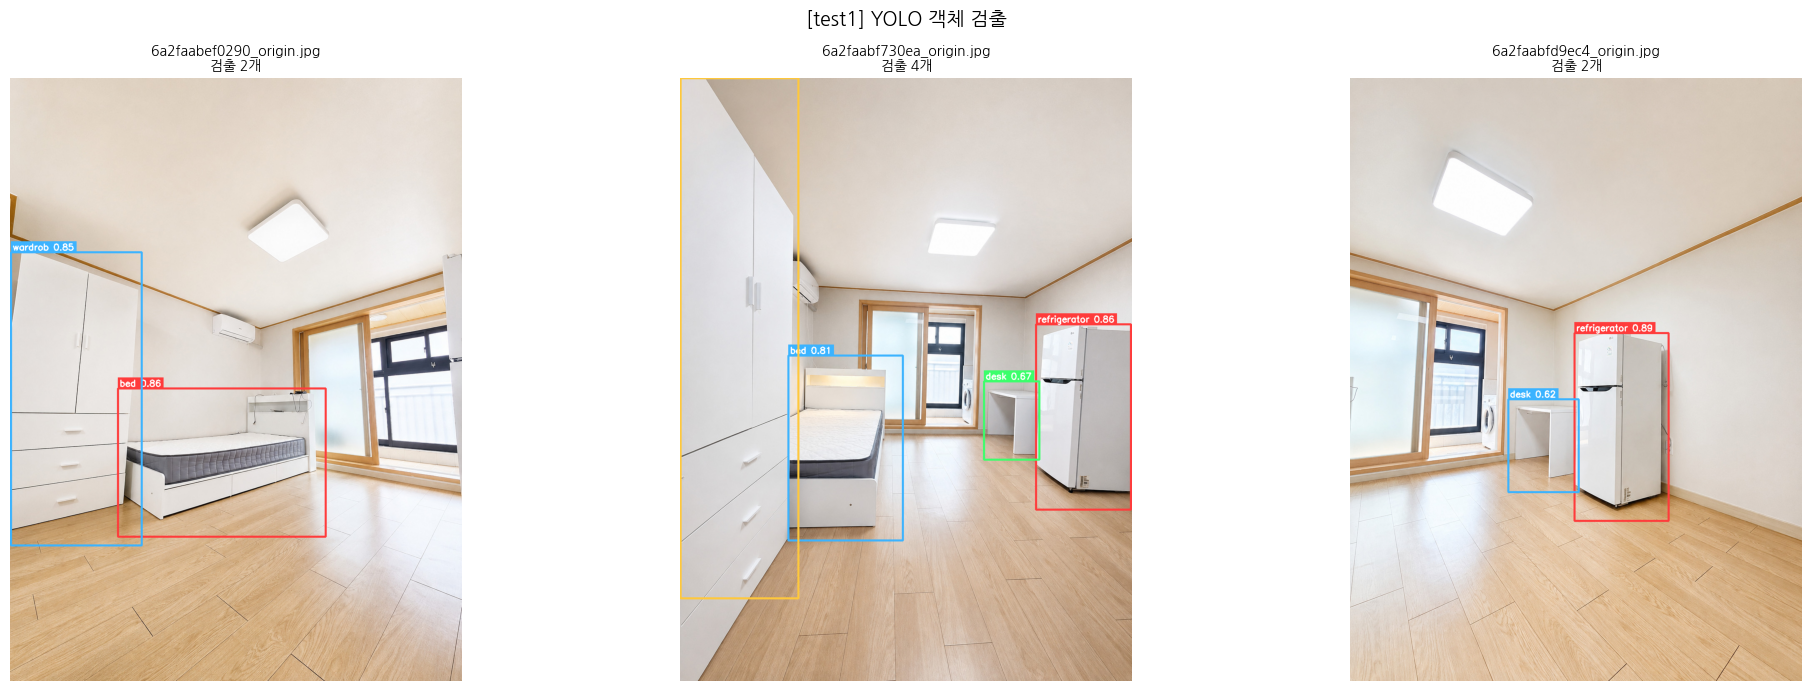

In [53]:
# 검출 결과 시각화 (바운딩 박스 + 라벨)
COLORS = [
    (255, 59, 59), (59, 179, 255), (59, 255, 107),
    (255, 200, 59), (200, 59, 255), (255, 130, 59),
]

n = len(img_paths)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, path, result in zip(axes, img_paths, results_yolo):
    img = np.array(Image.open(path).convert("RGB"))

    for i, box in enumerate(result.boxes):
        cls_name = model_yolo.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = COLORS[i % len(COLORS)]

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        label = f"{cls_name} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img, (x1, y1 - th - 10), (x1 + tw + 8, y1), color, -1)
        cv2.putText(img, label, (x1 + 4, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    ax.imshow(img)
    ax.set_title(f"{os.path.basename(path)}\n검출 {len(result.boxes)}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] YOLO 객체 검출", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_yolo.png", dpi=150, bbox_inches="tight")
plt.show()

### SAM2

In [12]:
!pip install -q sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SAM2 predictor 로드 (체크포인트 자동 다운로드)
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")
print("SAM2 모델 로드 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 16.5 MB/s eta 0:00:00


sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

SAM2 모델 로드 완료


In [54]:
def get_masks_from_yolo(img_path, yolo_result, predictor):
    """YOLO 박스를 프롬프트로 SAM2 마스크 생성. (이미지, 마스크들, 박스들, 라벨들) 반환"""
    img = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]

    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        predictor.set_image(img)
        masks_out, boxes_out, labels_out = [], [], []

        for box in yolo_result.boxes:
            cls_name = model_yolo.names[int(box.cls)]
            xyxy = box.xyxy[0].cpu().numpy()

            # 박스 크기 키우기 (padding) - 이불 등 누락 방지를 위해 더 넓게 설정
            pad = 10
            x1 = max(0, xyxy[0] - pad)
            y1 = max(0, xyxy[1] - pad)
            x2 = min(W - 1, xyxy[2] + pad)
            y2 = min(H - 1, xyxy[3] + pad)
            padded_xyxy = np.array([x1, y1, x2, y2], dtype=np.float32)

            # multimask_output=True로 설정하여 3개의 마스크(부분, 중간, 전체)를 받음
            masks, scores, _ = predictor.predict(box=padded_xyxy, multimask_output=True)

            # 가장 면적이 넓은 마스크를 선택하여 이불과 침대가 한 덩어리로 묶이도록 유도
            best_idx = np.argmax([m.sum() for m in masks])
            best_mask = masks[best_idx]

            masks_out.append(best_mask)
            boxes_out.append(padded_xyxy)
            labels_out.append(cls_name)

    return img, masks_out, boxes_out, labels_out


# 전체 이미지에 마스크 생성
all_results = []
for path, yolo_result in zip(img_paths, results_yolo):
    img, masks, boxes, labels = get_masks_from_yolo(path, yolo_result, predictor)
    all_results.append({"path": path, "img": img, "masks": masks,
                        "boxes": boxes, "labels": labels})
    print(f"{os.path.basename(path)}: 마스크 {len(masks)}개")

6a2faabef0290_origin.jpg: 마스크 2개
6a2faabf730ea_origin.jpg: 마스크 4개
6a2faabfd9ec4_origin.jpg: 마스크 2개


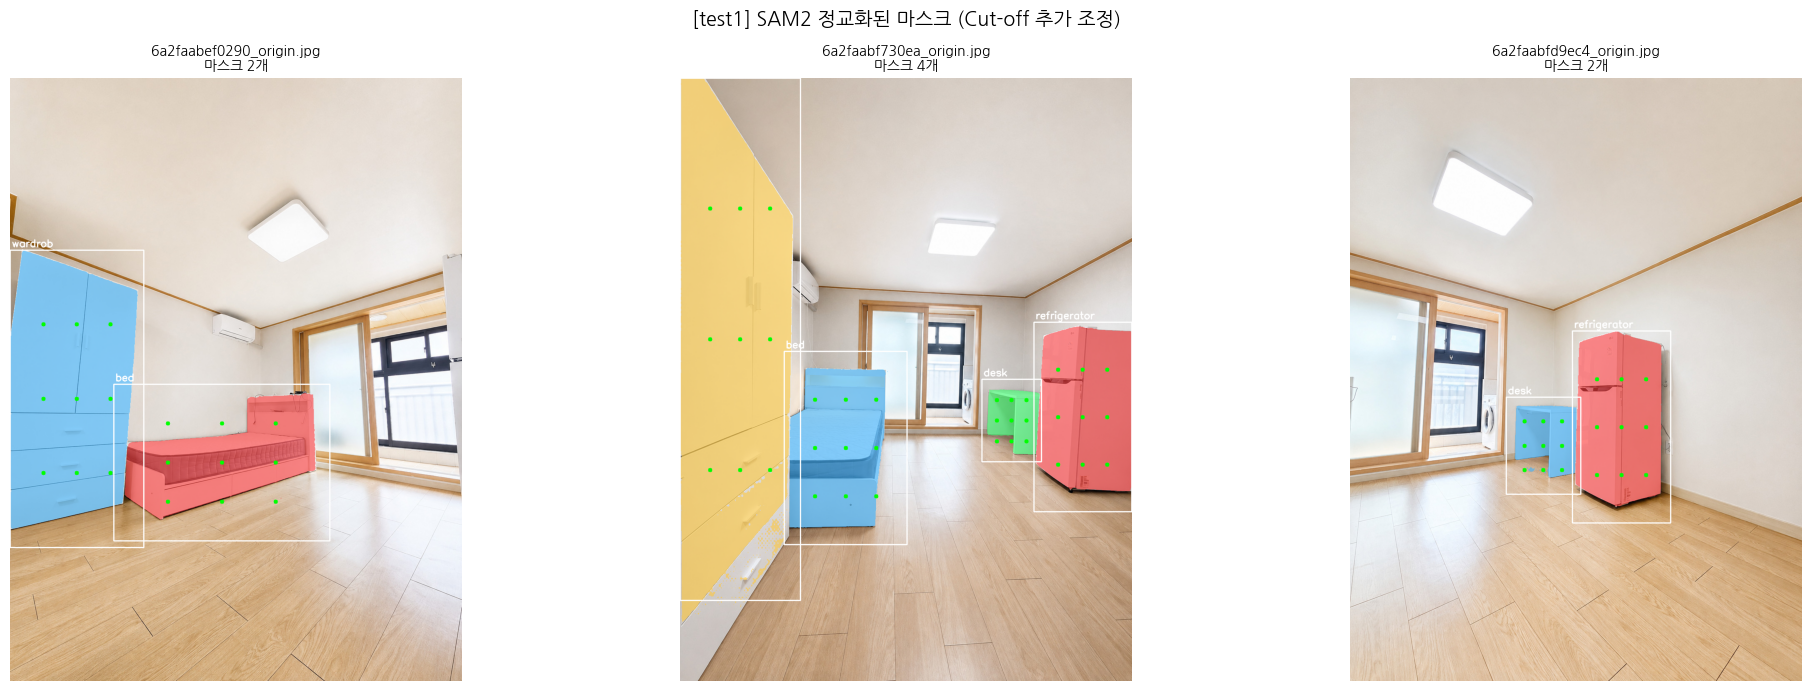

In [55]:
def get_masks_from_yolo_refined(img_path, yolo_result, predictor):
    img = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]

    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        predictor.set_image(img)

        masks_out, boxes_out, labels_out = [], [], []

        for box in yolo_result.boxes:
            cls_name = model_yolo.names[int(box.cls)]
            xyxy = box.xyxy[0].cpu().numpy()

            x1, y1, x2, y2 = xyxy

            # =========================
            # 1. 클래스별 padding
            # =========================
            if cls_name == "bed":
                pad = 10
            else:
                pad = 5

            x1 = max(0, x1 - pad)
            y1 = max(0, y1 - pad)
            x2 = min(W - 1, x2 + pad)
            y2 = min(H - 1, y2 + pad)

            padded_xyxy = np.array([x1, y1, x2, y2], dtype=np.float32)

            # =========================
            # 2. 클래스별 point 설정
            # =========================
            if cls_name == "bed":
                # bed는 아래쪽 중심 위주
                points = np.array([
                    [x1 + 0.50 * (x2 - x1), y1 + 0.45 * (y2 - y1)],
                    [x1 + 0.30 * (x2 - x1), y1 + 0.55 * (y2 - y1)],
                    [x1 + 0.70 * (x2 - x1), y1 + 0.55 * (y2 - y1)],
                    [x1 + 0.35 * (x2 - x1), y1 + 0.75 * (y2 - y1)],
                    [x1 + 0.65 * (x2 - x1), y1 + 0.75 * (y2 - y1)],
                ], dtype=np.float32)

            else:
                # 나머지 객체는 기존 3x3 방식 유지
                grid_x = np.linspace(x1, x2, 5)[1:-1]
                grid_y = np.linspace(y1, y2, 5)[1:-1]
                xv, yv = np.meshgrid(grid_x, grid_y)
                points = np.stack([xv.flatten(), yv.flatten()], axis=1)

            point_labels = np.ones(len(points), dtype=np.int32)

            masks, scores, logits = predictor.predict(
                box=padded_xyxy,
                point_coords=points,
                point_labels=point_labels,
                multimask_output=True
            )

            # =========================
            # 3. 클래스별 mask 선택
            # =========================
            if cls_name == "bed":
                # bed는 score보다 면적이 중요함
                bbox_area = (x2 - x1) * (y2 - y1)

                best_mask = None
                best_value = -1

                for m, s in zip(masks, scores):
                    m = m.astype(bool)
                    ratio = m.sum() / bbox_area

                    # 이불만 잡힌 경우 방지
                    if ratio < 0.20:
                        continue

                    # 배경까지 너무 크게 잡힌 경우 방지
                    if ratio > 1.20:
                        continue

                    value = ratio + float(s)

                    if value > best_value:
                        best_value = value
                        best_mask = m

                if best_mask is None:
                    best_idx = np.argmax([m.sum() for m in masks])
                    best_mask = masks[best_idx].astype(bool)

            else:
                # 나머지 객체는 기존 방식과 비슷하게 score 기준
                best_idx = np.argmax(scores)

                best_logit = logits[best_idx]

                if best_logit.ndim == 3 and best_logit.shape[0] == 1:
                    best_logit = best_logit[0]

                best_logit_resized = cv2.resize(
                    best_logit,
                    (W, H),
                    interpolation=cv2.INTER_LINEAR
                )

                custom_threshold = 0.3
                best_mask = best_logit_resized > custom_threshold

            masks_out.append(best_mask)
            boxes_out.append(padded_xyxy)
            labels_out.append(cls_name)

    return img, masks_out, boxes_out, labels_out
# 전체 이미지에 대해 정교화된 마스크 생성 재실행
all_results = []
for path, yolo_result in zip(img_paths, results_yolo):
    img, masks, boxes, labels = get_masks_from_yolo_refined(path, yolo_result, predictor)
    all_results.append({"path": path, "img": img, "masks": masks,
                        "boxes": boxes, "labels": labels})

def draw_masks(img, masks, labels):
    """이미지 위에 반투명 마스크 오버레이"""
    overlay = img.copy().astype(np.float32)
    for i, mask in enumerate(masks):
        color = np.array(COLORS[i % len(COLORS)], dtype=np.float32)
        mask_bool = mask.astype(bool)   # float -> bool 변환
        overlay[mask_bool] = overlay[mask_bool] * 0.4 + color * 0.6
    return overlay.astype(np.uint8)

# 마스크 시각화
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, res in zip(axes, all_results):
    masked_img = draw_masks(res["img"], res["masks"], res["labels"])
    for box, label in zip(res["boxes"], res["labels"]):
        x1, y1 = int(box[0]), int(box[1])
        cv2.putText(masked_img, label, (x1 + 4, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        # 패딩된 박스 시각화
        cv2.rectangle(masked_img, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (255, 255, 255), 2)

        # 3x3 그리드 포인트 시각화
        grid_x = np.linspace(box[0], box[2], 5)[1:-1]
        grid_y = np.linspace(box[1], box[3], 5)[1:-1]
        xv, yv = np.meshgrid(grid_x, grid_y)
        points = np.stack([xv.flatten(), yv.flatten()], axis=1)
        for pt in points:
            cv2.circle(masked_img, (int(pt[0]), int(pt[1])), 5, (0, 255, 0), -1)

    ax.imshow(masked_img)
    ax.set_title(f"{os.path.basename(res['path'])}\n마스크 {len(res['masks'])}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] SAM2 정교화된 마스크 (Cut-off 추가 조정)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_sam2_refined_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 정렬 좌표 생성 (핵심)

DUSt3R raw 좌표 → GLB 변환 → 바닥 RANSAC 정렬까지 한 번에 처리한다.
이 좌표계(`all_pts`, `ALIGN_TRANSFORM`)가 이후 GLB 저장, 스케일 계산, 거리 측정에서 공통으로 쓰인다.
높이축은 Y(=1).

In [56]:
import trimesh
from scipy.spatial.transform import Rotation

try:
    from dust3r.demo import OPENGL
except ImportError:
    from dust3r.viz import OPENGL

cams2world = scene.get_im_poses().detach().cpu().numpy()
_rot = np.eye(4)
_rot[:3, :3] = Rotation.from_euler("y", np.deg2rad(180)).as_matrix()
GLB_TRANSFORM = np.linalg.inv(cams2world[0] @ OPENGL @ _rot)


def apply_transform(points, T):
    """(N,3) 점에 4x4 변환 적용"""
    pts_h = np.concatenate([points, np.ones((len(points), 1))], axis=1)
    out = (T @ pts_h.T).T
    return out[:, :3]


def find_floor_rotation(points, up_axis=1, n_iter=2000):
    """RANSAC으로 바닥 평면을 검출하고, 그 법선을 +Y축에 맞추는 4x4 회전 행렬 반환"""
    height = points[:, up_axis]
    floor_candidates = points[height <= np.percentile(height, 35)]
    if len(floor_candidates) < 3:
        return np.eye(4), np.array([0.0, 1.0, 0.0])

    diag = np.linalg.norm(points.max(0) - points.min(0))
    threshold = diag * 0.02

    best_inliers, best_normal = -1, np.array([0.0, 1.0, 0.0])
    for _ in range(n_iter):
        idx = np.random.choice(len(floor_candidates), 3, replace=False)
        p1, p2, p3 = floor_candidates[idx]
        normal = np.cross(p2 - p1, p3 - p1)
        nrm = np.linalg.norm(normal)
        if nrm < 1e-6:
            continue
        normal = normal / nrm
        d = -np.dot(normal, p1)
        dist = np.abs(floor_candidates @ normal + d)
        ninl = int((dist < threshold).sum())
        if ninl > best_inliers:
            best_inliers, best_normal = ninl, normal

    if best_normal[up_axis] < 0:
        best_normal = -best_normal

    target = np.array([0.0, 1.0, 0.0])
    v = np.cross(best_normal, target)
    s = np.linalg.norm(v)
    c = float(np.dot(best_normal, target))
    if s < 1e-8:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s * s))

    T = np.eye(4)
    T[:3, :3] = R
    return T, best_normal


# DUSt3R 결과에서 바로 포인트/색상 수집 (YOLO·SAM2 불필요)
pointmaps = scene.get_pts3d()
confidences = scene.get_conf()

_all_pts_raw, _all_cols = [], []
for i, pts in enumerate(pointmaps):
    pts_np = pts.detach().cpu().numpy().reshape(-1, 3)
    conf_np = confidences[i].detach().cpu().numpy().flatten()
    mask = conf_np > CONF_THR
    h, w = pts.shape[:2]
    img_resized = np.array(images_pil[i].resize((w, h))).reshape(-1, 3)
    _all_pts_raw.append(pts_np[mask])
    _all_cols.append(img_resized[mask])
_all_pts_raw = np.concatenate(_all_pts_raw, axis=0)
all_cols = np.concatenate(_all_cols, axis=0) / 255.0

_all_pts_glb = apply_transform(_all_pts_raw, GLB_TRANSFORM)
FLOOR_ROT, floor_normal = find_floor_rotation(_all_pts_glb)
print(f"검출된 바닥 법선(GLB좌표): [{floor_normal[0]:+.2f}, {floor_normal[1]:+.2f}, {floor_normal[2]:+.2f}]")

ALIGN_TRANSFORM = FLOOR_ROT @ GLB_TRANSFORM


def align_points(points_raw):
    """raw DUSt3R 좌표(N,3) -> 정렬 좌표(N,3). 바닥이 수평, +Y가 위."""
    return apply_transform(points_raw, ALIGN_TRANSFORM)


all_pts = align_points(_all_pts_raw)

print(f"\n정렬 완료. 전체 포인트 수: {len(all_pts):,}")
print("이제 all_pts 는 바닥이 수평으로 정렬된 좌표다. 높이축은 Y(=1).")


검출된 바닥 법선(GLB좌표): [-0.03, +0.99, +0.10]

정렬 완료. 전체 포인트 수: 567,539
이제 all_pts 는 바닥이 수평으로 정렬된 좌표다. 높이축은 Y(=1).


## 3-1. 객체 라벨링 (SAM2 마스크 -> 통합 점군)

섹션 3에서 만든 `all_pts`는 confidence 필터만 거친 전체 점군이라 객체 라벨이 없다.
여기서 뷰별 SAM2 마스크(셀: SAM2 마스크 생성)를 `all_pts`와 같은 순서로 정렬해
점마다 라벨을 붙인다.

정합의 핵심:
- DUSt3R 점은 512 리사이즈 그리드(h, w) 기준 -> SAM2 마스크는 원본 크기라 (w, h)로 리사이즈
- 두 단계 모두 `img_paths` 순서를 그대로 따르고, 점은 `reshape(-1, 3)` + `conf > CONF_THR`로 수집
- 따라서 뷰별로 같은 마스크를 적용한 뒤 conf 마스크로 동일하게 걸러내면 순서가 일치한다

한 픽셀이 여러 마스크에 겹치면 박스 면적이 작은(=더 구체적인) 라벨을 우선한다.


In [66]:
import cv2

# 통합 점군에 붙일 라벨 배열. "" = 미분류(배경/바닥/벽)
point_labels = np.empty(len(all_pts), dtype=object)
point_labels[:] = ""

# 어떤 라벨을 객체로 다룰지 (박스형 큰 가구만. 비정형/소형은 bbox가 부정확해 제외)
TARGET_LABELS = {
    "bed",
    "refrigerator",
    "chair",
    "laptop",
    "wardrob",
    "desk"
}

_offset = 0  # all_pts 안에서 현재 뷰가 차지하는 시작 위치
for vi, pts in enumerate(pointmaps):
    h, w = pts.shape[:2]
    conf_np = confidences[vi].detach().cpu().numpy().flatten()
    conf_mask = conf_np > CONF_THR        # 셀 22와 동일 기준
    n_view = int(conf_mask.sum())         # 이 뷰가 all_pts에 기여한 점 수

    res = all_results[vi]                 # SAM2 결과 (셀 19)
    # 라벨 우선순위: 박스 면적 작은 것부터 (작은 객체가 큰 객체에 안 묻히게)
    order = sorted(range(len(res["masks"])),
                   key=lambda k: (res["boxes"][k][2]-res["boxes"][k][0]) *
                                 (res["boxes"][k][3]-res["boxes"][k][1]),
                   reverse=True)

    view_label_flat = np.empty(h * w, dtype=object)
    view_label_flat[:] = ""
    for k in order:
        lbl = res["labels"][k]
        if lbl not in TARGET_LABELS:
            continue
        # 원본 크기 마스크 -> (w,h) 점 그리드 크기로 리사이즈 (nearest)
        m = res["masks"][k].astype(np.uint8)
        m_resized = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
        view_label_flat[m_resized.flatten()] = lbl

    # conf 마스크로 걸러 all_pts 순서에 맞춰 채워넣기
    point_labels[_offset:_offset + n_view] = view_label_flat[conf_mask]
    _offset += n_view

assert _offset == len(all_pts), f"정합 실패: {_offset} != {len(all_pts)}"

# 라벨별 점 수 출력
uniq, cnts = np.unique(point_labels, return_counts=True)
print("=== SAM2 원본 라벨 (흡수 전) ===")
for u, c in sorted(zip(uniq, cnts), key=lambda x: -x[1]):
    name = u if u else "(미분류)"
    print(f"  {name:15s}: {c:>7,}점")


=== SAM2 원본 라벨 (흡수 전) ===
  (미분류)          : 469,066점
  wardrob        :  55,131점
  refrigerator   :  19,970점
  bed            :  19,034점
  desk           :   4,338점


## 3-2. Oriented bbox 흡수

라벨별로 점들을 모아 X-Z 평면(바닥면)에서 회전 사각형(`cv2.minAreaRect`)을 구하고,
Y(높이)는 바닥부터 객체 최대 높이까지로 잡아 직육면체를 만든다. 그 박스 안에 들어오는
모든 점을 같은 라벨로 재라벨링한다.

- DBSCAN으로 light-ray 아티팩트(경계 픽셀이 먼 바닥/벽으로 투영)를 먼저 제거 -> 박스가 안 부풀게
- Y 상한은 95퍼센타일로 robust하게 (천장 아티팩트가 박스를 세로로 늘리는 것 방지)
- MARGIN은 매트리스 경계만 흡수할 최소값. 키우면 벽/옆가구를 먹으니 주의

이 단계 후 `point_labels`가 갱신된다. 다른 뷰에서 누락된 매트리스 점이 침대 박스 안으로
흡수된다.


In [67]:
from sklearn.cluster import DBSCAN

# floor_peak: 바닥 Y 위치. 셀 22 정렬 기준 바닥은 Y 하위에 모임 -> 하위 퍼센타일로 추정
# (섹션 5에서 정식 floor_peak를 구하지만 여긴 그 앞이라 근사값 사용)
floor_peak = np.percentile(all_pts[:, 1], 5)

# 좌표계 스케일 대비 파라미터 (점군 단위가 임의라 전체 크기에 비례시킨다)
_diag = np.linalg.norm(all_pts.max(0) - all_pts.min(0))
EPS    = _diag * 0.012   # DBSCAN 이웃 반경
MARGIN = _diag * 0.008   # 박스 여유

def absorb_label(lbl):
    """lbl로 잡힌 점들을 oriented bbox로 감싸고, 박스 내부 점을 모두 lbl로 재라벨링."""
    sel = point_labels == lbl
    if sel.sum() < 50:
        print(f"  {lbl}: 점 부족({sel.sum()}) -> 건너뜀")
        return 0
    pts = all_pts[sel]

    # 1) DBSCAN으로 최대 클러스터만 (아티팩트 제거)
    lab = DBSCAN(eps=EPS, min_samples=20).fit_predict(pts[:, [0, 2]])
    if (lab >= 0).any():
        main = np.bincount(lab[lab >= 0]).argmax()
        pts = pts[lab == main]

    # 2) X-Z 회전 사각형
    xz = pts[:, [0, 2]].astype(np.float32)
    (cx, cz), (w, l), ang = cv2.minAreaRect(xz)
    w += 2 * MARGIN; l += 2 * MARGIN

    # 3) Y 범위 (바닥 ~ 95퍼센타일 높이)
    y_min = floor_peak
    y_max = np.percentile(pts[:, 1], 95) + MARGIN

    # 4) 전체 점군을 박스 로컬좌표로 변환해 내부 판정
    th = np.deg2rad(ang)
    R = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
    xz_loc = (all_pts[:, [0, 2]] - [cx, cz]) @ R.T
    inside = ((np.abs(xz_loc[:, 0]) <= w/2) & (np.abs(xz_loc[:, 1]) <= l/2) &
              (all_pts[:, 1] >= y_min) & (all_pts[:, 1] <= y_max))

    before = sel.sum()
    point_labels[inside] = lbl
    added = int(inside.sum()) - int(before)
    print(f"  {lbl:15s}: {before:>6,} -> {int(inside.sum()):>6,}점 "
          f"(+{added:,}) | 박스 {w:.2f}x{l:.2f}x{y_max-y_min:.2f}, 회전 {ang:.0f}도")
    return added

print("=== oriented bbox 흡수 ===")
_present = [u for u in np.unique(point_labels) if u]
for lbl in _present:
    absorb_label(lbl)

print("\n=== 흡수 후 라벨별 점 수 ===")
uniq, cnts = np.unique(point_labels, return_counts=True)
for u, c in sorted(zip(uniq, cnts), key=lambda x: -x[1]):
    print(f"  {(u if u else '(미분류)'):15s}: {c:>7,}점")


=== oriented bbox 흡수 ===
  bed            : 19,034 -> 22,854점 (+3,820) | 박스 0.26x0.12x0.08, 회전 -43도
  desk           :  4,338 ->  6,005점 (+1,667) | 박스 0.13x0.07x0.08, 회전 -36도
  refrigerator   : 19,970 -> 27,350점 (+7,380) | 박스 0.10x0.07x0.15, 회전 -85도
  wardrob        : 54,560 -> 60,321점 (+5,761) | 박스 0.10x0.04x0.18, 회전 -52도

=== 흡수 후 라벨별 점 수 ===
  (미분류)          : 450,737점
  wardrob        :  61,595점
  refrigerator   :  27,568점
  bed            :  21,633점
  desk           :   6,006점


## 3-3. 라벨 검증 (top-view + side-view)

흡수가 제대로 됐는지 눈으로 확인한다. 두 가지를 본다:
- **매트리스 등 누락분이 흡수됐나** (객체 박스가 실제 가구를 덮나)
- **옆 바닥·벽·다른 가구를 잘못 먹지 않았나** (박스가 과하게 크지 않나)

top-view(X-Z)는 가구 배치를, side-view(X-Y)는 높이 방향 흡수를 보여준다.
박스가 옆 가구를 먹었다면 그 라벨만 MARGIN을 줄이거나 EPS를 조정한다.


/tmp/ipykernel_1103/3090126383.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


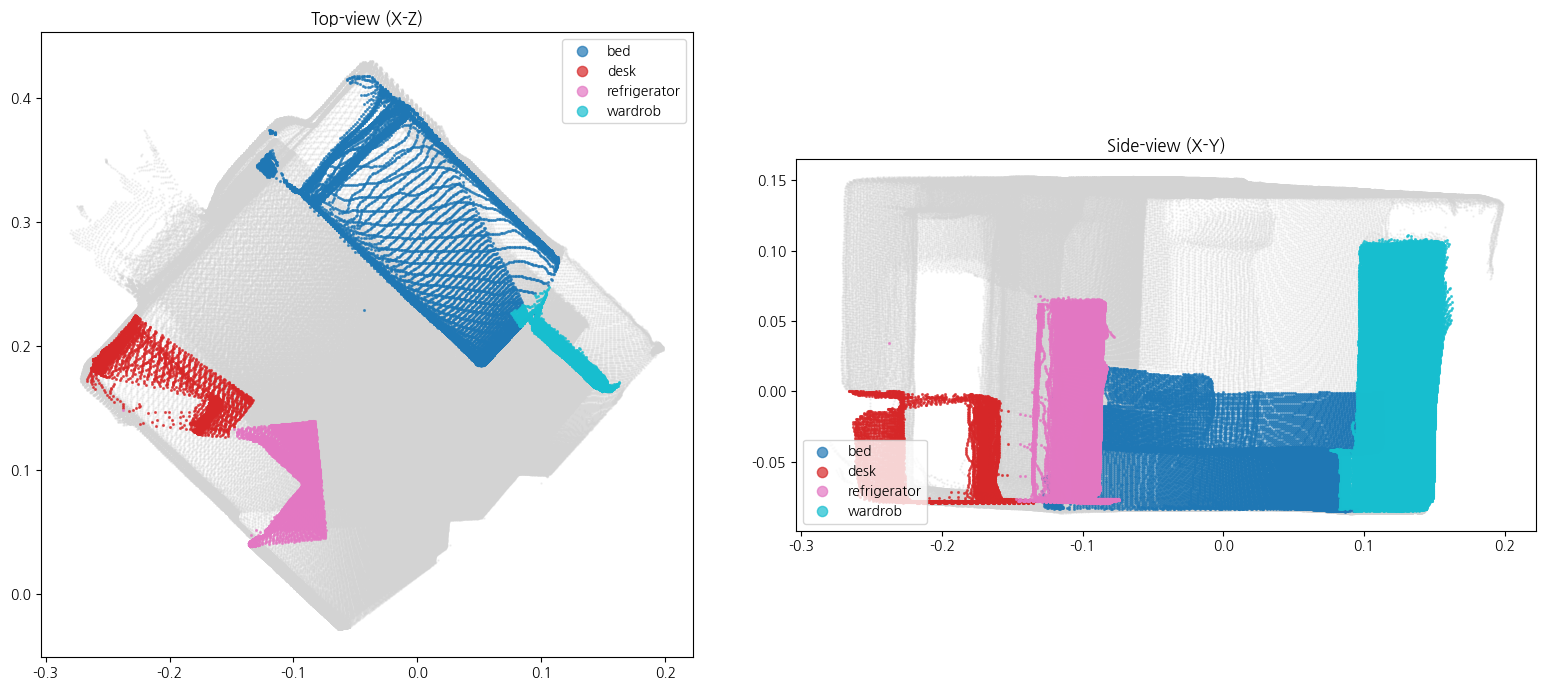

확인: 객체 색이 실제 가구 위치를 덮고, 바닥/벽(회색)을 침범하지 않아야 정상.
박스가 옆 가구를 먹었으면 해당 라벨의 MARGIN을 줄이거나 EPS를 조정하라.


In [69]:
import matplotlib.pyplot as plt

_present = [u for u in np.unique(point_labels) if u]
_cmap = plt.cm.tab10(np.linspace(0, 1, max(len(_present), 1)))
_color_of = {lbl: _cmap[i] for i, lbl in enumerate(_present)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 미분류 점 (배경) 회색으로 깔기
bg = point_labels == ""
for ax, (a, b), name in [(axes[0], (0, 2), "Top-view (X-Z)"),
                         (axes[1], (0, 1), "Side-view (X-Y)")]:
    ax.scatter(all_pts[bg, a], all_pts[bg, b], s=0.5, c="lightgray", alpha=0.3)
    for lbl in _present:
        sel = point_labels == lbl
        ax.scatter(all_pts[sel, a], all_pts[sel, b], s=1.5,
                   color=_color_of[lbl], label=lbl, alpha=0.7)
    ax.set_title(name); ax.set_aspect("equal"); ax.legend(markerscale=6)

plt.tight_layout()
plt.show()

print("확인: 객체 색이 실제 가구 위치를 덮고, 바닥/벽(회색)을 침범하지 않아야 정상.")
print("박스가 옆 가구를 먹었으면 해당 라벨의 MARGIN을 줄이거나 EPS를 조정하라.")


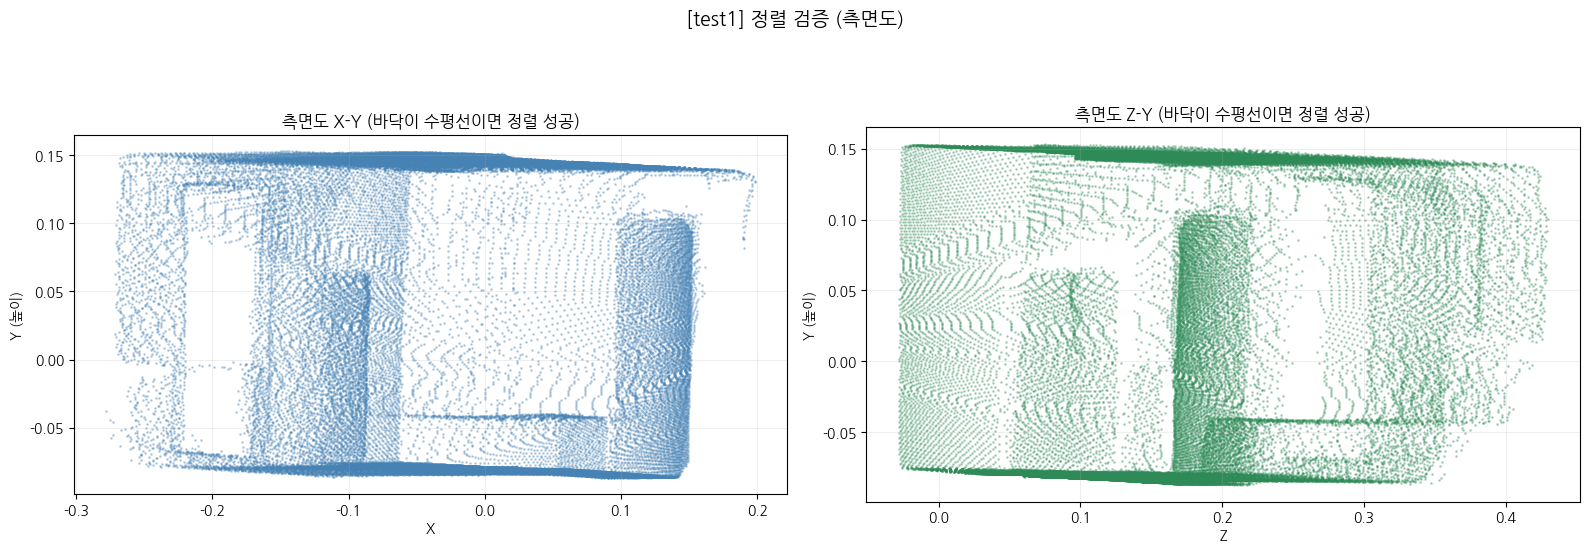

>> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.
>> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.


In [70]:
# 정렬 검증: 바닥이 정말 수평이 됐는지 측면도로 확인
# 정렬이 잘 됐으면 바닥 점들의 Y값이 좁은 띠에 모이고, 벽은 수직으로 선다.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 측면도 (X-Y): 바닥이 수평선으로 보여야 정상
axes[0].scatter(all_pts[::10, 0], all_pts[::10, 1], c="steelblue", s=1, alpha=0.3)
axes[0].set_title("측면도 X-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y (높이)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.2)

# 또 다른 측면도 (Z-Y)
axes[1].scatter(all_pts[::10, 2], all_pts[::10, 1], c="seagreen", s=1, alpha=0.3)
axes[1].set_title("측면도 Z-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[1].set_xlabel("Z"); axes[1].set_ylabel("Y (높이)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.2)

plt.suptitle(f"[{TARGET_FOLDER}] 정렬 검증 (측면도)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print(">> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.")
print(">> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.")


## 4. 3D 모델 저장 (GLB)

객체 라벨 색상 구분 없이 포인트클라우드 전체를 저장한다.

In [71]:
import open3d as o3d
from google.colab import files

# 영문 파일명 (한글명은 다운로드가 멈춤). 폴더명이 한글이어도 출력은 영문으로 고정.
SAFE_NAME = "room"


def clean_pointcloud(points, colors=None, n_neighbors=20, std_ratio=2.0):
    """통계적 이상치 제거"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    clean, _ = pcd.remove_statistical_outlier(n_neighbors, std_ratio)
    pts = np.asarray(clean.points)
    cols = np.asarray(clean.colors) if colors is not None else None
    return pts, cols


def save_pointcloud_glb(target_name, clean_depth=True):
    room_pts, room_cols = all_pts, all_cols
    if clean_depth:
        room_pts, room_cols = clean_pointcloud(room_pts, room_cols)

    pcd = trimesh.PointCloud(
        vertices=room_pts,
        colors=(room_cols * 255).astype(np.uint8),
    )
    scene_export = trimesh.Scene()
    scene_export.add_geometry(pcd, geom_name="room")

    glb_path = f"/content/{target_name}_pointcloud.glb"
    scene_export.export(glb_path)
    print("저장 완료:", glb_path)
    return glb_path


pcd_glb = save_pointcloud_glb(SAFE_NAME, clean_depth=True)
files.download(pcd_glb)


저장 완료: /content/room_pointcloud.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. 천장고 기반 스케일 계산

DUSt3R는 상대 좌표만 복원하므로 실측 거리(m)를 얻으려면 스케일 기준이 필요하다.
한국 원룸의 천장고는 보통 2.3~2.4m로 표준화돼 있어 이를 기준으로 삼는다.

방법: Y(높이) 히스토그램에서 바닥/천장 봉우리 간격을 구하고, 이를 실측 천장고에 맞춰 SCALE을 역산한다.
(단순 min-max는 노이즈로 과대평가되므로 쓰지 않는다.)

In [72]:
CEILING_CANDIDATES = [2.3, 2.4]   # 한국 주거 천장고 표준
UP_AXIS = 1

up = all_pts[:, UP_AXIS]

# 천장고 = Y 히스토그램 바닥/천장 봉우리 간격 (min-max는 노이즈로 과대평가)
hist, edges = np.histogram(up, bins=80)
centers = (edges[:-1] + edges[1:]) / 2
n = len(centers)
floor_peak = centers[:int(n*0.35)][np.argmax(hist[:int(n*0.35)])]
ceil_peak  = centers[int(n*0.65):][np.argmax(hist[int(n*0.65):])]
ceiling_raw = ceil_peak - floor_peak

print(f"바닥 봉우리 Y = {floor_peak:.4f}")
print(f"천장 봉우리 Y = {ceil_peak:.4f}")
print(f"천장고(raw 봉우리 간격) = {ceiling_raw:.4f}")
print(f"(참고) 단순 min-max = {up.max()-up.min():.4f}  <- 노이즈로 과대평가")

print()
for ceil_m in CEILING_CANDIDATES:
    scale = ceil_m / ceiling_raw
    print(f"[천장고 {ceil_m}m 가정] SCALE = {scale:.4f}  (raw 1 단위 = {scale:.4f} m)")

# 거리 측정에 쓸 SCALE: 2.3m 기준
SCALE = CEILING_CANDIDATES[0] / ceiling_raw
print(f"\n>> 거리 측정에 사용할 SCALE = {SCALE:.4f} (천장고 {CEILING_CANDIDATES[0]}m 기준)")


바닥 봉우리 Y = -0.0796
천장 봉우리 Y = 0.1455
천장고(raw 봉우리 간격) = 0.2251
(참고) 단순 min-max = 0.2401  <- 노이즈로 과대평가

[천장고 2.3m 가정] SCALE = 10.2180  (raw 1 단위 = 10.2180 m)
[천장고 2.4m 가정] SCALE = 10.6622  (raw 1 단위 = 10.6622 m)

>> 거리 측정에 사용할 SCALE = 10.2180 (천장고 2.3m 기준)


**확인 포인트 — 천장고 스케일 검증**
- 바닥/천장 봉우리가 히스토그램에서 또렷한 두 덩어리로 보여야 정상이다. 애매하게 퍼져 있으면 정렬(섹션 3) 실패 가능성이 크다.
- 2.3m와 2.4m 기준 SCALE 차이가 크지 않으면(±5% 이내) 안정적인 신호다.
- 이 SCALE이 거리 측정 결과의 정확도를 그대로 좌우한다.

## 6. 두 점 클릭 거리 측정 (Three.js)

포인트클라우드를 브라우저에서 직접 렌더링하고, 클릭으로 두 점을 찍어 실측 거리를 잰다.
Plotly `FigureWidget`이 Colab에서 클릭 콜백을 못 잡는 문제가 있어 Three.js + 단일 HTML 셀로 교체했다.

별도 서버나 백엔드 연동이 필요 없다 — `IPython.display.HTML()`로 출력 영역에 그대로 렌더링되는 정적 HTML/JS 한 덩어리다.
`all_pts`(raw 정렬 좌표)와 `SCALE`을 그대로 JSON으로 박아 넣고, 거리 계산은 JS에서 `raw_distance * SCALE`로 처리한다.

사용법: 셀 실행 → 아래 뜨는 3D 뷰에서 마우스 드래그로 회전, 휠로 줌 → 점 두 개를 순서대로 클릭하면 빨간 선과 함께 거리(m)가 표시된다.
우측 상단 'Reset' 버튼으로 재측정. 가구 배치 단계로 확장할 때 `furnitureGroup`에 GLB를 얹는 구조로 그대로 재사용 가능하다.

In [74]:
# 메시 모드용 데이터 준비: DUSt3R 내장 헬퍼로 텍스처 메시를 만들고 ALIGN_TRANSFORM을 적용한다.
# (섹션 4 포인트클라우드 GLB와 같은 좌표계를 쓰므로 점 모드/메시 모드 측정값이 서로 일치한다.)
#
# 이 셀은 방 메시를 "방"과 "가구별"로 분리해서 만든다. 핵심은 풀 메시를 만드는
# 그 valid mask(msk) 하나를 기준으로 삼고, 거기서 가구 픽셀만 떼어내는 것이다.
# 이렇게 하면 방 정점과 가구 정점이 같은 픽셀 그리드에서 나와 좌표가 완벽히 맞고,
# 가구를 끄면 딱 그 자리만 구멍이 난다. (영구 삭제가 아니라 메시 분리 + 토글)
from dust3r.demo import pts3d_to_trimesh, cat_meshes
from dust3r.utils.device import to_numpy

# 공간 구조에 의미 있는 큰 가구만 분리 대상으로 둔다.
TARGET_LABELS = {
    "bed",
    "refrigerator",
    "chair",
    "laptop",
    "wardrob",
    "desk"
}


def merge_label(label):
    # 라벨 통합이 필요하면 여기서 매핑한다. 현재는 그대로 사용.
    return label


def build_room_meshes(scene, all_results, min_conf_thr=3, clean_depth=True):
    """방 메시를 방/가구별로 분리해 dict로 반환한다.

    반환: {"room": Trimesh, "bed": Trimesh, ...}  (정렬 좌표계 적용 완료)
    분리 원리: 풀 메시가 쓰는 valid mask(msk)를 기준으로,
      - 가구 k 메시 = msk & (가구 k 마스크)
      - 방 메시      = msk & ~(모든 가구 마스크 합집합)
    셋의 valid는 서로 겹치지 않고 합치면 원래 msk와 같다.
    """
    if clean_depth:
        scene = scene.clean_pointcloud()

    rgbimg = scene.imgs
    pts3d = to_numpy(scene.get_pts3d())
    scene.min_conf_thr = float(scene.conf_trf(torch.tensor(min_conf_thr)))
    msk_raw = to_numpy(scene.get_masks())   # 풀 메시가 쓰는 바로 그 valid 기준
    # dtype이 bool이 아닐 수 있어(float/int) 명시적으로 강제한다.
    # 강제 안 하면 & 연산이 비트 단위로 깨져서 room_valid가 거의 비어버린다.
    msk = [np.asarray(m).astype(bool) for m in msk_raw]

    n_img = len(rgbimg)

    # 이미지별로 가구 라벨 -> 픽셀 마스크(메시 해상도로 리사이즈)를 모은다.
    # all_results는 원본 이미지 해상도이므로 메시 픽셀 그리드(H,W)로 맞춰준다.
    furn_union = []        # 이미지별 (H,W) bool: 가구가 점유한 픽셀 전체
    furn_per_label = []    # 이미지별 {label: (H,W) bool}
    for i in range(n_img):
        H, W = msk[i].shape[:2]
        union = np.zeros((H, W), bool)
        per = {}
        res = all_results[i]
        for j, label in enumerate(res["labels"]):
            label = merge_label(label)
            if label not in TARGET_LABELS:
                continue
            m = cv2.resize(res["masks"][j].astype(np.uint8), (W, H),
                           interpolation=cv2.INTER_NEAREST).astype(bool)
            per[label] = per.get(label, np.zeros((H, W), bool)) | m
            union |= m
        furn_union.append(union)
        furn_per_label.append(per)

    # 등장한 가구 라벨 전체 집합
    all_labels = sorted({lab for per in furn_per_label for lab in per})

    def _meshes_from_valid(valid_list):
        """이미지별 valid mask 리스트 -> 합쳐진 Trimesh (정렬 좌표 적용)."""
        pieces = []
        for i in range(n_img):
            if valid_list[i].sum() < 3:
                continue
            piece = pts3d_to_trimesh(rgbimg[i], pts3d[i], valid_list[i])
            if len(piece["faces"]):
                pieces.append(piece)
        if not pieces:
            return None
        mesh = trimesh.Trimesh(**cat_meshes(pieces))
        mesh.apply_transform(ALIGN_TRANSFORM)
        return mesh

    out = {}

    # 방: 풀 valid에서 가구 픽셀을 제외
    room_valid = [msk[i] & ~furn_union[i] for i in range(n_img)]
    # 디버그: room valid 픽셀 수가 비정상적으로 적으면 바로 알 수 있게 출력
    for i in range(n_img):
        print(f"  [img{i}] msk={msk[i].sum()} furn={furn_union[i].sum()} room_valid={room_valid[i].sum()}")
    out["room"] = _meshes_from_valid(room_valid)

    # 가구별: 풀 valid와 해당 가구 마스크의 교집합
    for label in all_labels:
        obj_valid = []
        for i in range(n_img):
            m = furn_per_label[i].get(label, np.zeros_like(msk[i], dtype=bool))
            obj_valid.append(msk[i] & m)
        m_obj = _meshes_from_valid(obj_valid)
        if m_obj is not None:
            out[label] = m_obj

    return out


room_parts = build_room_meshes(scene, all_results, min_conf_thr=3, clean_depth=True)

# 호환용: 기존 셀 31(원본 측정 위젯)이 쓰는 통합 room_mesh도 그대로 만들어 둔다.
# (방 + 모든 가구를 합치면 분리 전의 풀 메시와 동일하다.)
room_mesh = trimesh.util.concatenate([m for m in room_parts.values() if m is not None])

print("메시 분리 완료:")
for name, m in room_parts.items():
    if m is not None:
        print(f"  {name:14s}: 정점 {len(m.vertices):>7,}개 / 면 {len(m.faces):>7,}개")
print(f"  {'(합계) room_mesh':14s}: 정점 {len(room_mesh.vertices):>7,}개 / 면 {len(room_mesh.faces):>7,}개")

# 기존 셀 31 호환용 페이로드 (통합 메시 기준) — 원본 측정 위젯이 그대로 동작한다.
_mesh_vertices_payload = room_mesh.vertices.astype(np.float32).tolist()
_mesh_faces_payload = room_mesh.faces.astype(np.int32).tolist()
if hasattr(room_mesh.visual, "vertex_colors"):
    _mesh_colors_payload = (room_mesh.visual.vertex_colors[:, :3].astype(np.float32) / 255.0).tolist()
else:
    _mesh_colors_payload = [[0.8, 0.8, 0.8]] * len(room_mesh.vertices)


  [img0] msk=164525 furn=31259 room_valid=140531
  [img1] msk=168800 furn=56183 room_valid=118390
  [img2] msk=167244 furn=12359 room_valid=155324
메시 분리 완료:
  room          : 정점 408,992개 / 면 1,572,404개
  bed           : 정점  18,237개 / 면  69,634개
  desk          : 정점   4,016개 / 면  14,668개
  refrigerator  : 정점  16,101개 / 면  62,442개
  wardrob       : 정점  47,470개 / 면 183,448개
  (합계) room_mesh: 정점 494,816개 / 면 1,902,596개


## 4-2. Backdrop 채우기 (가구에 가려진 바닥/벽 복원)

가구를 끄면 그 자리에 구멍이 남는다(DUSt3R는 가려진 면을 못 봄). 방 바닥 외곽을 다각형으로 따서 실제 벽/바닥보다 살짝 뒤로 민 평평한 배경 메시를 만들고, 그 색을 근처 실제 점들의 평균색으로 채운다. `room_parts["backdrop"]`으로 등록되어 가구 토글과 독립적으로 켜고 끌 수 있다.

In [75]:
# extrude 대신 직접 면 구성 (triangulation 엔진 불필요)
# =========================================================
# [추가] Backdrop 생성 - 가구에 가려진 바닥+벽 채우기
#   입력: all_pts(정렬 좌표, raw 단위), all_cols(0~1), point_labels,
#         floor_peak, ceil_peak, SCALE, room_parts
#   원리: 방 바닥 점유 외곽을 다각형으로 딴 뒤, 실제 벽/바닥보다 살짝
#         바깥(뒤)으로 민 평평한 배경(바닥 슬래브 + 벽)을 만든다.
#         가구가 가린 곳은 실제 메시에 구멍이 있으니 이 배경이 비쳐 보인다.
#   색: 배경 각 정점 위치에서 가장 가까운 '실제 바닥/벽 점'들의 평균색을 입힘.
#   * extrude_polygon(삼각형화 엔진 필요)을 피하고 벽/바닥 면을 직접 만든다.
# =========================================================
import numpy as np
import trimesh
from scipy import ndimage
from scipy.spatial import cKDTree
from shapely.geometry import Polygon as _ShapelyPolygon
from shapely.ops import unary_union

# --- 벽 외곽 산출 전략 선택 ---
#   "full_height"    : 바닥 띠 대신 벽 전체 높이(바닥~천장) 배경 점으로 외곽을 딴다.
#                       가구가 낮은 높이를 가려도 그 위쪽 벽면 데이터가 있으면 진짜 위치 복원.
#   "footprint_fill" : 기존처럼 바닥 띠만 쓰되, 가구 발자국(허리 높이 이하)을 점유 격자에
#                       채워 가구가 만드는 구멍 자체를 줄인다.
WALL_STRATEGY = "full_height"   # "full_height" 또는 "footprint_fill"로 바꿔서 비교

# --- 파라미터 ---
BD_CELL       = 0.05          # 바닥 점유 격자 한 칸 (m)
BD_FLOOR_BAND = (-0.03, 0.12) # 바닥 봉우리 기준 띠 (raw)
BD_CLOSE_IT   = 3             # 바닥 구멍 메우기 반복
BD_SMOOTH_IT  = 2             # 외곽 매끈화 반복
BD_APPROX_EPS = 0.008          # 다각형 단순화 강도 (외곽 둘레 대비 비율)
BD_PUSH       = 0.03 / SCALE  # 실제 벽/바닥보다 뒤로 미는 정도 (raw). z-fighting 방지
BD_SUBDIV_M   = 0.10          # 색 세분화 목표 변 길이 (m). 정점색 해상도를 결정
WALL_ZONE_TOP_MARGIN = 0.05 / SCALE   # full_height용: 천장 근처 아티팩트 제외 여유
FURN_FOOTPRINT_MAX_H = 0.9 / SCALE    # footprint_fill용: 가구 발자국으로 볼 높이 상한
FURN_UNION_MARGIN    = 0.05 / SCALE   # union 안전장치: 가구 둘레 여유

# ---------------------------------------------------------
# 1) 방 바닥 외곽 다각형 추출 (raw 단위 XZ)
# ---------------------------------------------------------
_is_bg   = (point_labels == "")
_y       = all_pts[:, 1]
_floor_band = _is_bg & (_y > floor_peak + BD_FLOOR_BAND[0]) & (_y < floor_peak + BD_FLOOR_BAND[1])

if WALL_STRATEGY == "full_height":
    _contour_mask = _is_bg & (_y > floor_peak + BD_FLOOR_BAND[0]) & (_y < ceil_peak - WALL_ZONE_TOP_MARGIN)
    print(f"[full_height] 외곽 산출용 점: {_contour_mask.sum():,} (기존 바닥 띠만: {_floor_band.sum():,})")
else:
    _contour_mask = _floor_band
    print(f"[footprint_fill] 외곽 산출용 점(바닥 띠): {_contour_mask.sum():,}")

_floor_xz_raw = all_pts[_contour_mask][:, [0, 2]]
print(f"바닥 띠 점 개수: {_floor_band.sum():,}")

_floor_xz_m = _floor_xz_raw * SCALE
_xmin, _zmin = _floor_xz_m.min(0) - BD_CELL * 3
_xmax, _zmax = _floor_xz_m.max(0) + BD_CELL * 3
_GW = int(np.ceil((_xmax - _xmin) / BD_CELL))
_GH = int(np.ceil((_zmax - _zmin) / BD_CELL))

_gx = np.clip(((_floor_xz_m[:, 0] - _xmin) / BD_CELL).astype(int), 0, _GW - 1)
_gz = np.clip(((_floor_xz_m[:, 1] - _zmin) / BD_CELL).astype(int), 0, _GH - 1)
_occ = np.zeros((_GH, _GW), dtype=bool)
_occ[_gz, _gx] = True

# footprint_fill 전략일 때만: 가구 발자국(허리 높이 이하)을 점유 격자에 추가
if WALL_STRATEGY == "footprint_fill":
    _furn_low = (point_labels != "") & (_y < floor_peak + FURN_FOOTPRINT_MAX_H)
    if _furn_low.any():
        _furn_low_xz_m = all_pts[_furn_low][:, [0, 2]] * SCALE
        _fgx = np.clip(((_furn_low_xz_m[:, 0] - _xmin) / BD_CELL).astype(int), 0, _GW - 1)
        _fgz = np.clip(((_furn_low_xz_m[:, 1] - _zmin) / BD_CELL).astype(int), 0, _GH - 1)
        _occ[_fgz, _fgx] = True
        print(f"  가구 발자국 {_furn_low.sum():,}점 격자에 추가")

_occ = ndimage.binary_closing(_occ, iterations=BD_CLOSE_IT)
_occ = ndimage.binary_fill_holes(_occ)
_lab, _nc = ndimage.label(_occ)
if _nc > 1:
    _sizes = ndimage.sum(np.ones_like(_lab), _lab, range(1, _nc + 1))
    _occ = (_lab == int(np.argmax(_sizes)) + 1)
_occ = ndimage.binary_opening(_occ, iterations=BD_SMOOTH_IT)
_occ = ndimage.binary_closing(_occ, iterations=BD_SMOOTH_IT)
_occ = ndimage.binary_fill_holes(_occ)

_area_m2 = _occ.sum() * BD_CELL * BD_CELL
print(f"방 바닥 점유 면적: {_area_m2:.2f} m^2 ({_area_m2/3.305785:.1f}평)")

_mask_u8 = (_occ.astype(np.uint8)) * 255
_contours, _ = cv2.findContours(_mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
_cnt = max(_contours, key=cv2.contourArea)
_peri = cv2.arcLength(_cnt, True)
_approx = cv2.approxPolyDP(_cnt, BD_APPROX_EPS * _peri, True)
print(f"방 외곽 꼭짓점 수: {len(_approx)}")

_poly_grid = _approx[:, 0, :].astype(float)
_poly_m = np.stack([
    _xmin + (_poly_grid[:, 0] + 0.5) * BD_CELL,
    _zmin + (_poly_grid[:, 1] + 0.5) * BD_CELL,
], axis=1)
_poly_raw = _poly_m / SCALE

_shp = _ShapelyPolygon(_poly_raw)
if not _shp.is_valid:
    _shp = _shp.buffer(0)

# ---------------------------------------------------------
# 1.5) [안전장치] 가구 침범 방지 union
#   전략과 무관하게 항상 적용. 벽 폴리곤이 가구를 침범하면 union으로 밀어낸다.
#   면적 변화 로그로 각 전략이 애초에 얼마나 정확했는지(변화가 작을수록 좋음) 비교 가능.
# ---------------------------------------------------------
_furn_labels_present = [u for u in np.unique(point_labels) if u]
_furn_polys = []
for _lbl in _furn_labels_present:
    _fp = all_pts[point_labels == _lbl][:, [0, 2]]
    if len(_fp) < 10:
        continue
    _hull = cv2.convexHull(_fp.astype(np.float32))[:, 0, :]
    _fpoly = _ShapelyPolygon(_hull).buffer(FURN_UNION_MARGIN)
    if _fpoly.is_valid and _fpoly.area > 0:
        _furn_polys.append(_fpoly)

if _furn_polys:
    _before_area = _shp.area
    _shp = unary_union([_shp] + _furn_polys)
    if _shp.geom_type == "MultiPolygon":
        _shp = max(_shp.geoms, key=lambda g: g.area)
    _grow = (_shp.area - _before_area) * SCALE * SCALE
    print(f"[{WALL_STRATEGY}] union 침범 보정: "
          f"{_before_area*SCALE*SCALE:.2f} -> {_shp.area*SCALE*SCALE:.2f} m^2 "
          f"(+{_grow:.3f} m^2 확장됨 -> 작을수록 원래 외곽선이 정확했다는 뜻)")

# ---------------------------------------------------------
# 2) 벽/바닥 메시를 직접 구성 (extrude_polygon 회피)
#    - 벽: 외곽 각 변을 위/아래로 이어 사각형(삼각형 2개)
#    - 바닥: shapely의 삼각형화(내장 ops) 대신, 외곽 변마다 중심점 기준
#            fan 삼각형. 오목 다각형은 shapely로 볼록 분해 후 fan.
# ---------------------------------------------------------
_shp_pushed = _shp.buffer(BD_PUSH, join_style=2)   # mitre join = 각진 벽 유지
if _shp_pushed.geom_type == "MultiPolygon":
    _shp_pushed = max(_shp_pushed.geoms, key=lambda g: g.area)

_ring = np.asarray(_shp_pushed.exterior.coords)[:-1]   # (K,2) = (x,z)
_K = len(_ring)

_y_floor = floor_peak - BD_PUSH
_y_ceil  = ceil_peak + BD_PUSH

# --- 벽: 각 변마다 사각형 (양면 다 필요 없음, 재질이 DoubleSide) ---
_wall_v = []
_wall_f = []
for k in range(_K):
    x0, z0 = _ring[k]
    x1, z1 = _ring[(k + 1) % _K]
    base = len(_wall_v)
    _wall_v += [[x0, _y_floor, z0], [x1, _y_floor, z1],
                [x1, _y_ceil,  z1], [x0, _y_ceil,  z0]]
    _wall_f += [[base, base + 1, base + 2], [base, base + 2, base + 3]]
_walls = trimesh.Trimesh(vertices=np.array(_wall_v, float),
                         faces=np.array(_wall_f, int), process=False)

# --- 바닥: shapely 삼각형화 없이, 오목까지 견디는 ear-clipping 직접 구현 ---
def _ear_clip(poly_xz):
    """단순 다각형(볼록/오목)을 삼각형 인덱스 리스트로. 구멍 없음 가정."""
    n = len(poly_xz)
    if n < 3:
        return []
    area2 = 0.0
    for i in range(n):
        x0, z0 = poly_xz[i]
        x1, z1 = poly_xz[(i + 1) % n]
        area2 += x0 * z1 - x1 * z0
    idx = list(range(n)) if area2 > 0 else list(range(n))[::-1]

    def _cross(o, a, b):
        return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])

    def _in_tri(p, a, b, c):
        d1 = _cross(a, b, p); d2 = _cross(b, c, p); d3 = _cross(c, a, p)
        neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
        pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
        return not (neg and pos)

    tris = []
    guard = 0
    while len(idx) > 3 and guard < 10000:
        guard += 1
        ear = False
        m = len(idx)
        for i in range(m):
            ia, ib, ic = idx[(i-1) % m], idx[i], idx[(i+1) % m]
            a, b, c = poly_xz[ia], poly_xz[ib], poly_xz[ic]
            if _cross(a, b, c) <= 0:
                continue
            bad = False
            for j in idx:
                if j in (ia, ib, ic):
                    continue
                if _in_tri(poly_xz[j], a, b, c):
                    bad = True; break
            if bad:
                continue
            tris.append((ia, ib, ic))
            del idx[i]
            ear = True
            break
        if not ear:
            break
    if len(idx) == 3:
        tris.append((idx[0], idx[1], idx[2]))
    return tris

_tris = _ear_clip(_ring)
if len(_tris) >= _K - 2:
    _floor_v = np.column_stack([_ring[:, 0],
                                np.full(_K, _y_floor),
                                _ring[:, 1]])
    _floor_f = np.array(_tris, int)
else:
    print("  ear-clip 실패 -> 중심 fan 폴백")
    _cen = _ring.mean(0)
    _floor_v = np.vstack([[_cen[0], _y_floor, _cen[1]],
                          np.column_stack([_ring[:, 0],
                                           np.full(_K, _y_floor),
                                           _ring[:, 1]])])
    _floor_f = np.array([[0, 1 + k, 1 + (k + 1) % _K] for k in range(_K)], int)

_slab = trimesh.Trimesh(vertices=_floor_v, faces=_floor_f, process=False)

_backdrop = trimesh.util.concatenate([_walls, _slab])

# ---------------------------------------------------------
# 2.5) 색 입히기 전 세분화
#   벽 사각형이 정점 4개뿐이면 벽 전체가 코너 색 4개의 그라데이션으로 보간된다.
#   정점 간격을 약 10cm로 줄여 정점색이 실제 벽/바닥 색 변화를 표현할 수 있게 한다.
# ---------------------------------------------------------
_bd_v_sub, _bd_f_sub = trimesh.remesh.subdivide_to_size(
    _backdrop.vertices, _backdrop.faces, max_edge=BD_SUBDIV_M / SCALE)
_backdrop = trimesh.Trimesh(vertices=_bd_v_sub, faces=_bd_f_sub, process=False)
print(f"backdrop 세분화(변 {BD_SUBDIV_M*100:.0f}cm 이하): "
      f"정점 {len(_backdrop.vertices):,} / 면 {len(_backdrop.faces):,}")

# ---------------------------------------------------------
# 3) 색 입히기 (A: 벽/바닥 분리 참조 + B: K 축소로 선명하게)
# ---------------------------------------------------------
BD_COLOR_K = 4   # 색 평균에 쓸 최근접 점 개수 (작을수록 선명, 3~5 권장)

_ref_all_pts  = all_pts[_is_bg]
_ref_all_cols = all_cols[_is_bg]
_ref_y = _ref_all_pts[:, 1]
_is_floor_ref = _ref_y < (floor_peak + BD_FLOOR_BAND[1])
_floor_ref_pts,  _floor_ref_cols  = _ref_all_pts[_is_floor_ref],  _ref_all_cols[_is_floor_ref]
_wall_ref_pts,   _wall_ref_cols   = _ref_all_pts[~_is_floor_ref], _ref_all_cols[~_is_floor_ref]

def _sample_colors(query_pts, ref_pts, ref_cols, fallback_pts, fallback_cols):
    """query 정점마다 ref 점 K개 중앙값 색. ref가 비면 fallback에서 뽑는다."""
    if len(ref_pts) < BD_COLOR_K:
        ref_pts, ref_cols = fallback_pts, fallback_cols
    tree = cKDTree(ref_pts)
    kq = min(BD_COLOR_K, len(ref_pts))
    _, idx = tree.query(query_pts, k=kq)
    if kq == 1:
        idx = idx[:, None]
    return np.median(ref_cols[idx], axis=1)

_bd_v = _backdrop.vertices
_bd_is_floor = _bd_v[:, 1] < (floor_peak + BD_FLOOR_BAND[1])

_bd_cols = np.zeros((len(_bd_v), 3), dtype=float)
_bd_cols[_bd_is_floor] = _sample_colors(
    _bd_v[_bd_is_floor], _floor_ref_pts, _floor_ref_cols, _ref_all_pts, _ref_all_cols)
_bd_cols[~_bd_is_floor] = _sample_colors(
    _bd_v[~_bd_is_floor], _wall_ref_pts, _wall_ref_cols, _ref_all_pts, _ref_all_cols)

_bd_cols_rgba = np.concatenate([
    (_bd_cols * 255).astype(np.uint8),
    np.full((len(_bd_cols), 1), 255, dtype=np.uint8),
], axis=1)
_backdrop.visual.vertex_colors = _bd_cols_rgba

# ---------------------------------------------------------
# 4) room_parts에 등록
# ---------------------------------------------------------
room_parts["backdrop"] = _backdrop
print(f"backdrop 생성 완료: 정점 {len(_backdrop.vertices):,} / 면 {len(_backdrop.faces):,}")
print(f"  바닥 Y={_y_floor:.4f}, 천장 Y={_y_ceil:.4f}, 높이(raw)={_y_ceil-_y_floor:.4f}")
print(f"  벽 면 {len(_walls.faces):,} / 바닥 면 {len(_slab.faces):,}")
print(">> 이제 '비교용 뷰어' 셀을 다시 실행하면 가구를 꺼도 채워진 바닥/벽이 보인다.")

[full_height] 외곽 산출용 점: 274,653 (기존 바닥 띠만: 209,030)
바닥 띠 점 개수: 209,030
방 바닥 점유 면적: 12.92 m^2 (3.9평)
방 외곽 꼭짓점 수: 10
[full_height] union 침범 보정: 12.40 -> 12.54 m^2 (+0.136 m^2 확장됨 -> 작을수록 원래 외곽선이 정확했다는 뜻)
backdrop 세분화(변 10cm 이하): 정점 152,299 / 면 292,378
backdrop 생성 완료: 정점 152,299 / 면 292,378
  바닥 Y=-0.0825, 천장 Y=0.1485, 높이(raw)=0.2310
  벽 면 142 / 바닥 면 69
>> 이제 '비교용 뷰어' 셀을 다시 실행하면 가구를 꺼도 채워진 바닥/벽이 보인다.


## 7. [비교용] Backdrop 채우기 뷰어

셀 39(기존 뷰어)와 나란히 비교. '채우기(backdrop)' 체크로 구멍 메움 효과를 켜고 끌 수 있다. 확인 후 둘 중 하나를 삭제하면 된다.

In [76]:
# =========================================================
# 메시 뷰어 v3 - 가구 라이브러리 배치 + UI 패널 정리
#   기반: 기존 뷰어(바닥 격자 OFF + 작은 측정점 + 거리 라벨)
#   추가:
#     - Drive의 furniture_glb/*.glb 를 base64로 HTML에 내장
#     - '가구 라이브러리' 버튼 -> 가구 선택 -> 바닥 클릭으로 배치
#     - 고스트 미리보기, 바닥 자동 스냅, ESC 취소
#     - 가구 GLB는 미터 단위이므로 1/SCALE 로 방 raw 좌표계에 맞춤
#     - 배치된 가구 클릭 = 선택(T 이동/R 회전/Del 삭제)
#     - 카메라 드래그 후 클릭이 측정점으로 찍히던 문제 수정 (드래그 가드)
#   UI: 좌측 '보기' 패널 / 우측 '가구·측정' 패널로 정리
#   출력: HTML 파일 저장 + 다운로드만 (inline display 없음 -> 노트북 저장 안전)
# =========================================================
import os
import glob
import base64
import json as _json
import numpy as np
import trimesh
from scipy.spatial import cKDTree

SIMPLIFY_RATIO = 0.3
FURN_DIR = "/content/drive/Othercomputers/내 노트북/Asac-DL-Team4/02_Data/furniture_glb"

_PART_COLORS = {
    "bed": "#ff4d4d",
    "refrigerator": "#4d7dff",
    "chair": "#39c46e",
    "laptop": "#b478ff",
    "book": "#ff66cc",
    "sink": "#39c46e",
    "tv": "#ffa033",
    "dining table": "#b478ff",
}

def _simplify(m, ratio):
    if ratio >= 1.0 or len(m.faces) < 1000:
        return m
    try:
        import fast_simplification
        v, f = fast_simplification.simplify(
            np.asarray(m.vertices, np.float64),
            np.asarray(m.faces, np.int64),
            target_reduction=1.0 - ratio,
        )
        new = trimesh.Trimesh(vertices=v, faces=f, process=False)
        if hasattr(m.visual, "vertex_colors") and len(m.visual.vertex_colors):
            _, idx = cKDTree(m.vertices).query(v)
            new.visual.vertex_colors = m.visual.vertex_colors[idx]
        return new
    except Exception as e:
        print(f"  simplify 건너뜀({e})")
        return m

_scene = trimesh.Scene()
_furn_meta = []

for name, m in room_parts.items():
    if m is None:
        continue

    m_s = _simplify(m, SIMPLIFY_RATIO)
    node = name.replace(" ", "_")
    _scene.add_geometry(m_s, node_name=node, geom_name=node)

    if not name.startswith("backdrop") and name != "room":
        _furn_meta.append({
            "name": name,
            "node": node,
            "swatch": _PART_COLORS.get(name, "#999999")
        })

_glb = _scene.export(file_type="glb")
_glb_b64 = base64.b64encode(_glb).decode("ascii")
print(f"방 GLB: {len(_glb)/1024/1024:.2f} MB")

# ---------------------------------------------------------
# 가구 라이브러리 로드 (furniture_glb_maker.ipynb 산출물)
#   - 미터 단위 GLB 규약 (바닥 Y=0, X/Z 중앙, +Y 위)
#   - 폴더가 없거나 비어 있어도 뷰어는 정상 동작
# ---------------------------------------------------------
furn_lib = []
if os.path.isdir(FURN_DIR):
    for _p in sorted(glob.glob(os.path.join(FURN_DIR, "*.glb"))):
        _key = os.path.splitext(os.path.basename(_p))[0]
        with open(_p, "rb") as _f:
            _b = base64.b64encode(_f.read()).decode("ascii")
        furn_lib.append({"key": _key, "label": _key, "b64": _b})
        print(f"  라이브러리 GLB: {_key} ({os.path.getsize(_p)/1024:.0f} KB)")
else:
    print(f"  가구 라이브러리 폴더 없음: {FURN_DIR}")
    print("  (drive.mount 후 furniture_glb_maker.ipynb 로 GLB를 만들어 두면 자동 반영)")

print(f"가구 라이브러리: {len(furn_lib)}개")

_HTML = r"""
<style>
  .hud{
    position:absolute;z-index:10;
    background:rgba(15,15,30,0.92);
    border:1px solid #3a3a6a;border-radius:12px;
    padding:12px 14px;font-family:sans-serif;
    box-shadow:0 4px 14px rgba(0,0,0,0.45);
    color:#ddd;font-size:13px;width:200px;
  }
  .hud-title{
    font-size:11px;font-weight:bold;color:#8b8bd0;
    letter-spacing:1px;margin:2px 0 8px 0;
  }
  .hud-title:not(:first-child){
    margin-top:14px;padding-top:10px;border-top:1px solid #2a2a4a;
  }
  .row{
    display:flex;justify-content:space-between;align-items:center;
    margin:6px 0;gap:8px;cursor:pointer;
  }
  .row span{color:#ccc;white-space:nowrap;}
  .row input[type=checkbox]{accent-color:#6366f1;cursor:pointer;}
  .slider-row{cursor:default;}
  .slider-row input[type=range]{width:105px;accent-color:#6366f1;}
  .btn{
    display:block;width:100%;box-sizing:border-box;
    margin:5px 0;padding:7px 10px;cursor:pointer;
    background:#2a2a4a;color:#ddd;border:1px solid #444;
    border-radius:7px;font-size:13px;text-align:left;
  }
  .btn:hover{background:#34345c;border-color:#6366f1;}
  .btn-accent{background:#4338ca;color:#fff;border-color:#6366f1;}
  .btn-accent:hover{background:#4f46e5;}
  .btn-file{position:relative;}
  .btn-file input{display:none;}
  .hint{
    margin-top:10px;padding-top:8px;border-top:1px solid #2a2a4a;
    font-size:11px;color:#888;line-height:1.6;
  }
  .subpanel{width:180px;display:none;}
  .subpanel .btn.active{background:#4338ca;border-color:#818cf8;}
  #info{
    position:absolute;bottom:16px;left:50%;transform:translateX(-50%);
    z-index:10;background:rgba(15,15,30,0.9);border:1px solid #3a3a6a;
    border-radius:20px;padding:7px 18px;font-family:sans-serif;
    font-size:13px;color:#aab;white-space:nowrap;display:none;
  }
</style>

<div id="wrap" style="width:100%;height:100vh;background:#111;position:relative;overflow:hidden;">

  <div class="hud" id="hud-left" style="top:12px;left:12px;">
    <div class="hud-title">보기</div>
    <label class="row"><span>채우기 (backdrop)</span><input type="checkbox" id="bd-toggle" checked></label>
    <label class="row"><span>바닥 격자</span><input type="checkbox" id="grid-toggle"></label>
    <label class="row"><span>높이</span><input type="checkbox" id="clip-toggle"></label>
    <div class="row slider-row"><span>단면 높이</span><input type="range" id="clip-slider" min="0" max="100" value="95"></div>
    <div class="row slider-row"><span>밝기</span><input type="range" id="bright-slider" min="0" max="200" value="100"></div>
  </div>

  <div class="hud" id="hud-right" style="top:12px;right:12px;">
    <div class="hud-title">가구</div>
    <button class="btn" id="furn-btn">기존 가구 목록 &#9662;</button>
    <button class="btn btn-accent" id="lib-btn">가구 라이브러리 &#9662;</button>
    <label class="btn btn-file">GLB 파일 불러오기<input type="file" id="furn-file" accept=".glb"></label>
    <button class="btn" id="clear-furn-btn">배치 가구 초기화</button>
    <div class="hud-title">측정</div>
    <button class="btn" id="reset-btn">측정 초기화</button>
    <div class="hint">
      배치 가구 클릭 = 선택<br>
      T 이동 &middot; R 회전 &middot; Del 삭제<br>
      ESC = 배치 모드 취소
    </div>
  </div>

  <div class="hud subpanel" id="panel" style="top:12px;right:226px;">
    <div class="hud-title">체크 해제 = 가구 빼기</div>
  </div>

  <div class="hud subpanel" id="libpanel" style="top:12px;right:226px;">
    <div class="hud-title">가구 선택 후 바닥 클릭</div>
  </div>

  <div id="info"></div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
<script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/TransformControls.js"></script>
<script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/loaders/GLTFLoader.js"></script>

<script>
(function(){
  const GLB_B64="__GLB__";
  const FURN=__FURN__;
  const SCALE=__SCALE__;
  const FURNLIB=__FURNLIB__;

  const wrap=document.getElementById("wrap");
  const infoEl=document.getElementById("info");
  const panel=document.getElementById("panel");
  const libpanel=document.getElementById("libpanel");

  function setInfo(msg){
    if(msg){
      infoEl.innerHTML=msg;
      infoEl.style.display="block";
    }else{
      infoEl.style.display="none";
    }
  }

  document.getElementById("furn-btn").onclick=function(){
    const open=panel.style.display!=="block";
    panel.style.display=open ? "block" : "none";
    if(open) libpanel.style.display="none";
  };

  document.getElementById("lib-btn").onclick=function(){
    const open=libpanel.style.display!=="block";
    libpanel.style.display=open ? "block" : "none";
    if(open) panel.style.display="none";
  };

  const W=wrap.clientWidth || window.innerWidth;
  const H=wrap.clientHeight || window.innerHeight;

  const scene=new THREE.Scene();
  scene.background=new THREE.Color(0x111111);

  const camera=new THREE.PerspectiveCamera(60,W/H,0.001,1000);
  const renderer=new THREE.WebGLRenderer({antialias:true});
  renderer.setSize(W,H);
  wrap.appendChild(renderer.domElement);

  const controls=new THREE.OrbitControls(camera,renderer.domElement);
  controls.enableDamping=true;
  controls.zoomSpeed=1.5;

  renderer.localClippingEnabled=true;

  const clipPlane=new THREE.Plane(new THREE.Vector3(0,-1,0),0);
  let floorY=0, ceilY=1, orbitR=1;
  let grid=null;
  let floorPlane=null;

  const clipToggle=document.getElementById("clip-toggle");
  const clipSlider=document.getElementById("clip-slider");
  const bdToggle=document.getElementById("bd-toggle");
  const gridToggle=document.getElementById("grid-toggle");

  const ambLight=new THREE.AmbientLight(0xffffff,0.95);
  scene.add(ambLight);

  const dl=new THREE.DirectionalLight(0xffffff,0.5);
  dl.position.set(1,1,1);
  scene.add(dl);

  document.getElementById("bright-slider").oninput=function(e){
    const f=e.target.value/100;
    ambLight.intensity=0.95*f;
    dl.intensity=0.5*f;
  };

  const tcontrols=new THREE.TransformControls(camera,renderer.domElement);
  tcontrols.setMode("translate");
  tcontrols.setSpace("world");
  scene.add(tcontrols);

  tcontrols.addEventListener("dragging-changed", function(e){
    controls.enabled=!e.value;
  });

  function b64buf(b){
    const s=atob(b);
    const n=s.length;
    const a=new Uint8Array(n);
    for(let i=0;i<n;i++){
      a[i]=s.charCodeAt(i);
    }
    return a.buffer;
  }

  const parts=[];
  const backdropParts=[];
  const placedFurn=[];
  let selected=null;

  // ── 가구 라이브러리 상태 ──
  const furnCache={};
  let placeKey=null;
  let ghost=null;

  function makeDistanceLabel(text){
    const canvas = document.createElement("canvas");
    const ctx = canvas.getContext("2d");

    canvas.width = 512;
    canvas.height = 128;

    ctx.fillStyle = "rgba(255,255,255,0.92)";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    ctx.strokeStyle = "rgba(255,0,0,0.9)";
    ctx.lineWidth = 6;
    ctx.strokeRect(3, 3, canvas.width - 6, canvas.height - 6);

    ctx.font = "bold 54px Arial";
    ctx.fillStyle = "red";
    ctx.textAlign = "center";
    ctx.textBaseline = "middle";
    ctx.fillText(text, canvas.width / 2, canvas.height / 2);

    const texture = new THREE.CanvasTexture(canvas);
    texture.needsUpdate = true;

    const material = new THREE.SpriteMaterial({
      map: texture,
      transparent: true,
      depthTest: false,
      depthWrite: false
    });

    const sprite = new THREE.Sprite(material);

    const s = 0.35 / SCALE;
    sprite.scale.set(s * 2.8, s * 0.7, 1);

    return sprite;
  }

  function applyClip(){
    const on=clipToggle.checked;
    clipSlider.style.opacity=on ? "1" : "0.4";

    const planes=on ? [clipPlane] : [];
    clipPlane.constant=floorY + (ceilY-floorY) * (clipSlider.value/100);

    parts.forEach(function(p){
      p.mesh.material.clippingPlanes=planes;
      p.mesh.material.clipShadows=true;
    });

    backdropParts.forEach(function(o){
      o.material.clippingPlanes=planes;
      o.material.clipShadows=true;
    });
  }

  clipToggle.onchange=applyClip;
  clipSlider.oninput=applyClip;

  new THREE.GLTFLoader().parse(b64buf(GLB_B64), "", function(g){
    scene.add(g.scene);

    g.scene.traverse(function(o){
      if(o.isMesh){
        o.material.vertexColors=true;
        o.material.metalness=0.0;
        o.material.roughness=1.0;
        o.material.depthTest=true;

        if(o.name.startsWith("backdrop")){
          backdropParts.push(o);

          o.material.side=THREE.DoubleSide;
          o.material.depthWrite=false;
          o.material.polygonOffset=true;
          o.material.polygonOffsetFactor=10;
          o.material.polygonOffsetUnits=10;
          o.renderOrder=-10;
          o.visible=bdToggle.checked;
        }else{
          o.material.side=THREE.DoubleSide;
          o.material.depthWrite=true;
          o.renderOrder=0;

          parts.push({
            node:o.name,
            mesh:o
          });
        }

        o.material.needsUpdate=true;
      }
    });

    const box=new THREE.Box3();

    parts.forEach(function(p){
      box.expandByObject(p.mesh);
    });

    const c=box.getCenter(new THREE.Vector3());
    const r=box.getSize(new THREE.Vector3()).length()*0.5;

    controls.target.copy(c);
    camera.position.copy(c).add(new THREE.Vector3(r*1.4,r*1.1,r*1.4));
    controls.update();

    orbitR=r;

    let minY = Infinity;
    let maxY = -Infinity;

    parts.forEach(function(p){
      const b = new THREE.Box3().setFromObject(p.mesh);
      minY = Math.min(minY, b.min.y);
      maxY = Math.max(maxY, b.max.y);
    });

    floorY = minY;
    ceilY = maxY;

    grid = new THREE.GridHelper(
      orbitR * 4,
      20,
      0x3355ff,
      0x1a2a4a
    );

    grid.position.set(c.x, floorY - 0.08, c.z);
    grid.material.transparent = true;
    grid.material.opacity = 0.12;
    grid.material.depthWrite = false;
    grid.visible = false;

    scene.add(grid);

    gridToggle.onchange=function(){
      if(grid){
        grid.visible = gridToggle.checked;
      }
    };

    // 배치용 raycast 바닥면 (보이지 않음)
    const pg=new THREE.PlaneGeometry(orbitR*8, orbitR*8);
    pg.rotateX(-Math.PI/2);
    floorPlane=new THREE.Mesh(pg, new THREE.MeshBasicMaterial({visible:false, side:THREE.DoubleSide}));
    floorPlane.position.set(c.x, floorY, c.z);
    scene.add(floorPlane);

    applyClip();
    buildPanel();
    buildLibPanel();

  }, function(e){
    setInfo("GLB 로드 실패: " + e);
    console.error(e);
  });

  bdToggle.onchange=function(){
    backdropParts.forEach(function(o){
      o.visible=bdToggle.checked;
    });
  };

  function buildPanel(){
    FURN.forEach(function(f){
      const tg=parts.filter(function(p){
        return p.node===f.node || p.node.indexOf(f.node)===0;
      });

      if(!tg.length) return;

      const id="c"+Math.random().toString(36).slice(2,8);
      const d=document.createElement("div");
      d.className="row";

      const lb=document.createElement("label");
      lb.htmlFor=id;
      lb.style.cssText="display:flex;align-items:center;cursor:pointer;color:#ddd;";

      const sw=document.createElement("span");
      sw.style.cssText=
        "display:inline-block;width:11px;height:11px;border-radius:2px;margin-right:7px;background:"+f.swatch+";";

      lb.appendChild(sw);
      lb.appendChild(document.createTextNode(f.name));

      const cb=document.createElement("input");
      cb.type="checkbox";
      cb.checked=true;
      cb.id=id;

      cb.onchange=function(){
        tg.forEach(function(t){
          t.mesh.visible=cb.checked;
        });
      };

      d.appendChild(lb);
      d.appendChild(cb);
      panel.appendChild(d);
    });
  }

  // ── 가구 라이브러리: 버튼 목록 ──
  function buildLibPanel(){
    if(!FURNLIB.length){
      const d=document.createElement("div");
      d.style.cssText="color:#888;font-size:12px;line-height:1.5;";
      d.textContent="라이브러리 비어있음 (Drive의 furniture_glb 폴더에 GLB를 넣으세요)";
      libpanel.appendChild(d);
      return;
    }
    FURNLIB.forEach(function(f){
      const b=document.createElement("button");
      b.id="lib-item-"+f.key;
      b.className="btn";
      b.textContent=f.label;
      b.onclick=function(){
        if(placeKey===f.key){ cancelPlace(); return; }
        setPlaceMode(f, b);
      };
      libpanel.appendChild(b);
    });
  }

  function resetLibButtons(){
    libpanel.querySelectorAll("button").forEach(function(b){
      b.classList.remove("active");
    });
  }

  function parseLibItem(f, done){
    if(furnCache[f.key]){ done(furnCache[f.key]); return; }
    new THREE.GLTFLoader().parse(b64buf(f.b64), "", function(g){
      const obj=g.scene;
      obj.traverse(function(o){
        if(o.isMesh){
          o.material.side=THREE.DoubleSide;
          if(o.material.map) o.material.map.encoding=THREE.sRGBEncoding;
          o.material.needsUpdate=true;
        }
      });
      // 가구 GLB는 미터 단위. 방은 raw 단위이므로 1/SCALE 로 맞춘다.
      obj.scale.setScalar(1.0/SCALE);
      furnCache[f.key]=obj;
      done(obj);
    }, function(err){
      setInfo("라이브러리 GLB 파싱 실패: "+f.key);
      console.error(err);
    });
  }

  function setPlaceMode(f, btn){
    cancelPlace();
    parseLibItem(f, function(tpl){
      placeKey=f.key;
      resetLibButtons();
      if(btn) btn.classList.add("active");
      ghost=tpl.clone();
      ghost.traverse(function(o){
        if(o.isMesh){
          o.material=o.material.clone();
          o.material.transparent=true;
          o.material.opacity=0.45;
          o.material.depthWrite=false;
        }
      });
      ghost.position.set(0,0,0);
      ghost.userData.bottom=new THREE.Box3().setFromObject(ghost).min.y;
      ghost.visible=false;
      scene.add(ghost);
      setInfo("배치 모드: 바닥 클릭으로 배치 &middot; ESC 취소");
    });
  }

  function cancelPlace(){
    placeKey=null;
    if(ghost){ scene.remove(ghost); ghost=null; }
    resetLibButtons();
    setInfo("");
  }

  function placeAt(key, point){
    const tpl=furnCache[key];
    if(!tpl) return;
    const obj=tpl.clone();
    obj.position.set(0,0,0);
    const bb=new THREE.Box3().setFromObject(obj);
    obj.position.set(point.x, floorY-bb.min.y, point.z);
    obj.userData.isFurniture=true;
    scene.add(obj);
    placedFurn.push(obj);
    setInfo(key+" 배치됨 &middot; 계속 클릭으로 추가 배치 &middot; ESC 종료");
  }

  document.getElementById("furn-file").addEventListener("change", function(e){
    const file=e.target.files[0];
    if(!file) return;

    const reader=new FileReader();

    reader.onload=function(ev){
      new THREE.GLTFLoader().parse(ev.target.result, "", function(g){
        const obj=g.scene;

        obj.traverse(function(o){
          if(o.isMesh){
            o.material.side=THREE.DoubleSide;
            o.material.needsUpdate=true;
          }
        });

        // 파일로 불러오는 GLB도 미터 단위 규약이면 아래 주석 해제
        // obj.scale.setScalar(1.0/SCALE);

        const bb=new THREE.Box3().setFromObject(obj);
        const bottomOffset=bb.min.y;

        obj.position.set(0, floorY-bottomOffset, 0);
        obj.userData.isFurniture=true;

        scene.add(obj);
        placedFurn.push(obj);
        selectFurn(obj);
      });
    };

    reader.readAsArrayBuffer(file);
    e.target.value="";
  });

  function selectFurn(obj){
    selected=obj;
    tcontrols.attach(obj);
  }

  function deselectFurn(){
    selected=null;
    tcontrols.detach();
  }

  document.getElementById("clear-furn-btn").onclick=function(){
    placedFurn.forEach(function(o){
      scene.remove(o);
    });
    placedFurn.length=0;
    deselectFurn();
    setInfo("");
  };

  window.addEventListener("keydown", function(e){
    if(e.key==="Escape") cancelPlace();
    if(e.key==="t" || e.key==="T") tcontrols.setMode("translate");
    if(e.key==="r" || e.key==="R") tcontrols.setMode("rotate");

    if((e.key==="Delete" || e.key==="Backspace") && selected){
      scene.remove(selected);
      const idx=placedFurn.indexOf(selected);
      if(idx>=0) placedFurn.splice(idx,1);
      deselectFurn();
    }
  });

  const ray=new THREE.Raycaster();
  const mouse=new THREE.Vector2();

  let sel=[];
  const mg=new THREE.Group();
  scene.add(mg);

  function resetMeas(){
    sel=[];
    while(mg.children.length){
      mg.remove(mg.children[0]);
    }
    setInfo("");
  }

  document.getElementById("reset-btn").onclick=resetMeas;

  // ── 고스트 미리보기 (배치 모드에서 마우스 따라다님) ──
  renderer.domElement.addEventListener("pointermove", function(e){
    if(!placeKey || !ghost || !floorPlane) return;
    const rc=renderer.domElement.getBoundingClientRect();
    mouse.x=((e.clientX-rc.left)/rc.width)*2-1;
    mouse.y=-((e.clientY-rc.top)/rc.height)*2+1;
    ray.setFromCamera(mouse,camera);
    const h=ray.intersectObject(floorPlane,false);
    if(h.length){
      ghost.visible=true;
      ghost.position.set(h[0].point.x, floorY-ghost.userData.bottom, h[0].point.z);
    }
  });

  // ── 클릭: 드래그 가드 -> 배치 -> 가구 선택 -> 측정 ──
  let downPos=null;

  renderer.domElement.addEventListener("pointerdown", function(e){
    downPos=[e.clientX, e.clientY];
  });

  renderer.domElement.addEventListener("click",function(e){
    // 카메라 드래그였으면 무시 (측정점이 잘못 찍히는 것 방지)
    if(downPos &&
       (Math.abs(e.clientX-downPos[0])>4 || Math.abs(e.clientY-downPos[1])>4)){
      return;
    }

    const rc=renderer.domElement.getBoundingClientRect();

    mouse.x=((e.clientX-rc.left)/rc.width)*2-1;
    mouse.y=-((e.clientY-rc.top)/rc.height)*2+1;

    ray.setFromCamera(mouse,camera);

    // 1) 배치 모드면 바닥 클릭 = 배치
    if(placeKey && floorPlane){
      const ph=ray.intersectObject(floorPlane,false);
      if(ph.length){
        placeAt(placeKey, ph[0].point);
        return;
      }
    }

    // 2) 배치된 가구 클릭 = 선택
    const furnTargets=[];
    placedFurn.forEach(function(o){
      o.traverse(function(c){
        if(c.isMesh) furnTargets.push(c);
      });
    });

    const fHits=ray.intersectObjects(furnTargets,false);
    if(fHits.length){
      let o=fHits[0].object;
      while(o.parent && !o.userData.isFurniture){
        o=o.parent;
      }
      if(o.userData.isFurniture){
        selectFurn(o);
        return;
      }
    }

    if(!tcontrols.dragging){
      deselectFurn();
    }

    // 3) 방/가구 메시 클릭 = 측정
    const vis=parts
      .filter(function(p){ return p.mesh.visible; })
      .map(function(p){ return p.mesh; });

    const h=ray.intersectObjects(vis,false);
    if(!h.length) return;

    const p=h[0].point.clone();

    if(sel.length>=2) resetMeas();

    sel.push(p);

    const m=new THREE.Mesh(
      new THREE.SphereGeometry(0.005,10,10),
      new THREE.MeshBasicMaterial({
        color:0xff3333,
        depthTest:false
      })
    );

    m.position.copy(p);
    mg.add(m);

    if(sel.length===2){
      const raw = sel[0].distanceTo(sel[1]);
      const me = raw * SCALE;

      setInfo(
        "<b>측정 거리: " + me.toFixed(3) + " m</b> " +
        "(raw=" + raw.toFixed(4) + ", SCALE=" + SCALE.toFixed(4) + ")"
      );

      mg.add(
        new THREE.Line(
          new THREE.BufferGeometry().setFromPoints([sel[0], sel[1]]),
          new THREE.LineBasicMaterial({
            color: 0xff0000,
            transparent: true,
            opacity: 0.9,
            depthTest: false
          })
        )
      );

      const mid = new THREE.Vector3()
        .addVectors(sel[0], sel[1])
        .multiplyScalar(0.5);

      const label = makeDistanceLabel(me.toFixed(2) + " m");
      label.position.copy(mid);
      label.renderOrder = 999;
      mg.add(label);
    }
  });

  window.addEventListener("resize", function(){
    const nw=wrap.clientWidth || window.innerWidth;
    const nh=wrap.clientHeight || window.innerHeight;
    camera.aspect=nw/nh;
    camera.updateProjectionMatrix();
    renderer.setSize(nw,nh);
  });

  (function loop(){
    requestAnimationFrame(loop);
    controls.update();
    renderer.render(scene,camera);
  })();

})();
</script>
"""

_HTML = _HTML.replace("__GLB__", _glb_b64)
_HTML = _HTML.replace("__FURN__", _json.dumps(_furn_meta))
_HTML = _HTML.replace("__SCALE__", str(float(SCALE)))
_HTML = _HTML.replace("__FURNLIB__", _json.dumps(furn_lib))

# inline display는 하지 않는다.
# 가구 b64까지 내장되어 HTML이 커졌으므로 출력에 남기면 노트북 저장이 실패한다.

_base = globals().get("SAFE_NAME", "room")
_out_path = f"/content/{_base}_viewer_v3.html"

_full_html = (
    "<!DOCTYPE html><html><head><meta charset='utf-8'>"
    "<title>Room Viewer</title>"
    "<style>body{margin:0;overflow:hidden;background:#111;}</style>"
    "</head><body>" + _HTML + "</body></html>"
)

with open(_out_path, "w", encoding="utf-8") as f:
    f.write(_full_html)

print(f"저장 완료: {_out_path} ({len(_full_html)/1024/1024:.2f} MB)")

from google.colab import files
files.download(_out_path)

  simplify 건너뜀(No module named 'fast_simplification')
  simplify 건너뜀(No module named 'fast_simplification')
  simplify 건너뜀(No module named 'fast_simplification')
  simplify 건너뜀(No module named 'fast_simplification')
  simplify 건너뜀(No module named 'fast_simplification')
  simplify 건너뜀(No module named 'fast_simplification')
방 GLB: 35.00 MB
  라이브러리 GLB: TV_meters (795 KB)
  라이브러리 GLB: 소파_meters (3200 KB)
가구 라이브러리: 2개
저장 완료: /content/room_viewer_v3.html (51.89 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>